# Canteen Food Waste Intelligence
### An End-to-End Statistical and Business Intelligence Analysis

---

## 1. Business Problem

Institutional canteens routinely prepare food in quantities that do not exactly match actual demand. The mismatch between **planned meals, meals prepared, and meals actually served** results in food waste, which carries a direct financial cost, an operational-planning cost, and a sustainability cost.

This project analyzes historical canteen service records to understand **how much food is wasted, why it is wasted, when it is wasted, and which items/meal periods drive the waste**, so that management can make evidence-based decisions.

## 2. Business Objectives

- Quantify the scale of food waste (in kg and in cost) across the canteen's operations.
- Identify which menu items, meal types, and waste reasons contribute most to total waste.
- Understand the statistical behavior of waste (typical values, variability, extreme events).
- Detect time-based patterns (day-of-week, monthly, trend over time).
- Segment records into risk categories to prioritize operational attention.
- Translate all findings into actionable, prioritized recommendations.

## 3. Business Questions

1. What does a "typical" food service record look like in terms of waste?
2. How variable is food waste — is it consistent or unpredictable?
3. Is waste concentrated in a small number of items (Pareto effect)?
4. Which meal types, menu items, or waste reasons are the biggest contributors?
5. Are there time-based patterns (day of week, month, trend)?
6. What conditions are associated with unusually high waste?
7. What operational thresholds should trigger investigation?
8. What should the canteen prioritize to reduce waste?

## 4. Technology Used

This notebook uses **only** `pandas`, `numpy`, `matplotlib`, and `seaborn`. No machine-learning or external statistical libraries (`scipy`, `sklearn`, `statsmodels`, etc.) are used. Wherever a technique would normally rely on one of those libraries, the underlying calculation is implemented directly with `pandas`/`numpy`, and any resulting limitation is explicitly stated.

## 5. Dataset

The dataset used is the actual canteen service log previously generated for this project (`Canteen_Food_Waste_Intelligence_MESSY.xlsx`). It is intentionally messy (missing values, inconsistent text, mixed data types, illogical entries, duplicates) — reflecting a realistic raw operational export. **No values, rows, or results in this notebook are fabricated; every number is computed from this dataset.**


## 6. Setup

We import the four permitted libraries and configure display/plotting defaults for consistent, readable output throughout the notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10

RANDOM_STATE = 42


## 7. Load the Dataset

We load the raw Excel file exactly as exported, with no pre-cleaning, so that the data-quality assessment in the next section reflects the true state of the raw data.

In [2]:
raw_df = pd.read_excel("Canteen_Food_Waste_Intelligence_MESSY.xlsx")
print("Raw dataset shape:", raw_df.shape)
raw_df.head(10)


Raw dataset shape: (2565, 16)


,Record_ID,Date,Meal_Type,Menu_Item,Planned_Meals,Meals_Prepared,Meals_Served,Meals_Leftover,Food_Prepared_kg,Food_Consumed_kg,Food_Wasted_kg,Waste_Type,Waste_Reason,Waste_Cost,Attendance_Count,Demand_Forecast
0,REC00450,NaN,Breakfast,NaN,485,653.00,432.00,221.00,367.42,223.97,143.45,Preparation Waste,Ingredient Spoilage,"5,661.26",301,369.00
1,REC00919,08 Dec 2024,Snacks,Cutlet,NaN,735.00,429.00,306.00,228.70,128.32,100.38,plate waste,NaN,"7,427.72",590,480.00
2,REC01668,02/09/2025,Snacks,Sandwich,386,403.00,283.00,120.00,194.66,113.37,81.29,Leftover,Poor Quality,"2,711.98",260,283.00
3,REC01455,19 Sep 2023,Dinner,paneer roti,648,705.00,391.00,314.00,246.71,NaN,105.07,Leftover,Special Event Cancelled,"6,075.91",529,518.00
4,REC01868,26/10/2025,Breakfast,Poha,744,956.00,730.00,226.00,399.57,283.38,116.19,Preparation Waste,Weather Impact,"5,038.44",662,534.00
5,REC01386,10/27/2023,Breakfast,Upma,NaN,412.00,352.00,60.00,140.57,110.71,29.86,Spoilage,Ingredient Spoilage,917.26,335,326.00
6,REC00044,24-06-2023,Breakfast,Idli Sambar,383,343.00,NaN,-70.00,133.88,134.81,-0.93,Preparation Waste,Menu Unpopularity,-33.90,286,364.00
7,REC00963,10/15/2025,Dinner,Paneer Roti,NaN,676.00,379.00,297.00,394.79,212.13,182.66,Spoilage,Overproduction,"11,968.07",462,477.00
8,REC01784,04/10/2025,Dinner,Veg Pulao,443,452.00,348.00,104.00,144.53,111.12,33.41,plate waste,Menu Unpopularity,NaN,719,516.00
9,REC00230,14-08-2025,Breakfast,Dosa,483,711.00,364.00,347.00,318.72,155.91,162.81,plate waste,overproduction,"5,026.77",401,360.00


## 8. Dataset Understanding

### What are we trying to understand?
Before any cleaning or analysis, we need to know exactly what columns exist, what they represent, and what data type each *should* be. This prevents us from analyzing the wrong variable or misinterpreting a column.

In [3]:
raw_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2565 entries, 0 to 2564
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Record_ID         2543 non-null   str    
 1   Date              2495 non-null   str    
 2   Meal_Type         2452 non-null   str    
 3   Menu_Item         2414 non-null   str    
 4   Planned_Meals     2351 non-null   object 
 5   Meals_Prepared    2392 non-null   float64
 6   Meals_Served      2421 non-null   float64
 7   Meals_Leftover    2294 non-null   float64
 8   Food_Prepared_kg  2367 non-null   float64
 9   Food_Consumed_kg  2373 non-null   float64
 10  Food_Wasted_kg    2428 non-null   float64
 11  Waste_Type        2181 non-null   str    
 12  Waste_Reason      2175 non-null   str    
 13  Waste_Cost        2256 non-null   object 
 14  Attendance_Count  2346 non-null   object 
 15  Demand_Forecast   2375 non-null   float64
dtypes: float64(7), object(3), str(6)
memory usage: 320.8+

### Data Dictionary

The table below documents each column as it exists in the raw dataset, its intended meaning, and its expected data type (which may differ from what Pandas inferred, due to data-quality issues we will fix in the cleaning stage).

In [4]:
data_dictionary = pd.DataFrame([
    ("Record_ID",        "Unique identifier for each service record",                         "Text (ID)"),
    ("Date",              "Date the meal was served",                                           "Date"),
    ("Meal_Type",         "Breakfast / Lunch / Snacks / Dinner",                                 "Category"),
    ("Menu_Item",         "Specific food item served",                                           "Category"),
    ("Planned_Meals",     "Number of meals planned in advance",                                  "Numeric (count)"),
    ("Meals_Prepared",    "Number of meals actually prepared",                                   "Numeric (count)"),
    ("Meals_Served",      "Number of meals actually served/consumed by diners",                  "Numeric (count)"),
    ("Meals_Leftover",    "Prepared meals remaining unserved (Prepared - Served)",               "Numeric (count)"),
    ("Food_Prepared_kg",  "Total weight of food prepared",                                       "Numeric (kg)"),
    ("Food_Consumed_kg",  "Total weight of food actually consumed",                              "Numeric (kg)"),
    ("Food_Wasted_kg",    "Total weight of food wasted",                                         "Numeric (kg)"),
    ("Waste_Type",        "Category of waste: Plate Waste, Leftover, Preparation Waste, Spoilage","Category"),
    ("Waste_Reason",      "Root cause of the waste event",                                       "Category"),
    ("Waste_Cost",        "Monetary value of the wasted food",                                   "Numeric (currency)"),
    ("Attendance_Count",  "Number of people present/expected at the meal",                       "Numeric (count)"),
    ("Demand_Forecast",   "Forecasted number of meals required",                                 "Numeric (count)"),
], columns=["Column", "Description", "Expected Type"])

data_dictionary


,Column,Description,Expected Type
0,Record_ID,Unique identifier for each service record,Text (ID)
1,Date,Date the meal was served,Date
2,Meal_Type,Breakfast / Lunch / Snacks / Dinner,Category
3,Menu_Item,Specific food item served,Category
4,Planned_Meals,Number of meals planned in advance,Numeric (count)
5,Meals_Prepared,Number of meals actually prepared,Numeric (count)
6,Meals_Served,Number of meals actually served/consumed by di...,Numeric (count)
7,Meals_Leftover,Prepared meals remaining unserved (Prepared - ...,Numeric (count)
8,Food_Prepared_kg,Total weight of food prepared,Numeric (kg)
9,Food_Consumed_kg,Total weight of food actually consumed,Numeric (kg)


## 9. Data Quality Assessment

### What are we trying to understand?
Real operational exports are rarely clean. Before trusting any statistic, we must quantify: missing values, duplicate records, inconsistent text formatting, mixed data types inside numeric columns, and logically impossible values (e.g., meals served exceeding meals prepared).

In [5]:
missing_count = raw_df.isna().sum()
missing_pct = (missing_count / len(raw_df) * 100).round(2)
dq_missing = pd.DataFrame({'Missing_Count': missing_count, 'Missing_Pct': missing_pct})
dq_missing = dq_missing[dq_missing['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
dq_missing


,Missing_Count,Missing_Pct
Waste_Reason,390,15.20
Waste_Type,384,14.97
Waste_Cost,309,12.05
Meals_Leftover,271,10.57
Attendance_Count,219,8.54
Planned_Meals,214,8.34
Food_Prepared_kg,198,7.72
Food_Consumed_kg,192,7.49
Demand_Forecast,190,7.41
Meals_Prepared,173,6.74


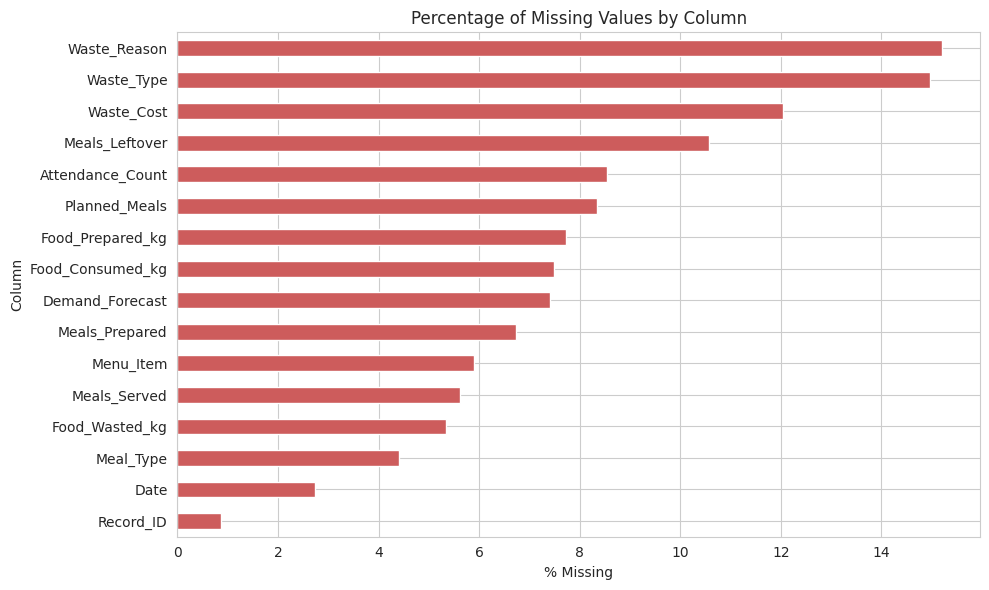

In [6]:
fig, ax = plt.subplots(figsize=(10,6))
dq_missing['Missing_Pct'].sort_values().plot(kind='barh', color='indianred', ax=ax)
ax.set_title('Percentage of Missing Values by Column')
ax.set_xlabel('% Missing')
ax.set_ylabel('Column')
plt.tight_layout()
plt.show()


**Interpretation:** Every column has some missing data, with `Waste_Reason`, `Waste_Type`, and `Meals_Leftover` the most affected (roughly 11-15%). This tells us the cleaning stage must handle missing categorical and numeric fields differently rather than dropping rows outright, since dropping every row with any missing value would remove a large share of the dataset.

In [7]:
# Fully blank rows (export artifacts)
fully_blank = raw_df.isna().all(axis=1).sum()
print("Fully blank rows:", fully_blank)

# Duplicate rows (exact duplicates across all columns)
exact_duplicates = raw_df.duplicated().sum()
print("Exact duplicate rows:", exact_duplicates)

# Duplicate Record_ID (should be unique)
dup_ids = raw_df['Record_ID'].duplicated(keep=False).sum()
print("Rows sharing a duplicated Record_ID:", dup_ids)


Fully blank rows: 5
Exact duplicate rows: 64
Rows sharing a duplicated Record_ID: 191


In [8]:
# Data type inspection: columns that SHOULD be numeric but pandas read as text/object
# because they contain junk strings like 'N/A', '--', 'unknown', '?'
candidate_numeric_cols = ['Planned_Meals', 'Waste_Cost', 'Attendance_Count']

for col in candidate_numeric_cols:
    non_numeric_values = raw_df[col][pd.to_numeric(raw_df[col], errors='coerce').isna() & raw_df[col].notna()]
    print(f"{col}: {non_numeric_values.nunique()} distinct non-numeric junk values ->",
          non_numeric_values.unique()[:10])


Planned_Meals: 3 distinct non-numeric junk values -> ['?' '--' 'unknown']
Waste_Cost: 3 distinct non-numeric junk values -> ['--' '?' 'unknown']
Attendance_Count: 3 distinct non-numeric junk values -> ['?' '--' 'unknown']


In [9]:
# Inconsistent text formatting in categorical columns
for col in ['Meal_Type', 'Waste_Type', 'Waste_Reason']:
    print(f"--- {col} ---")
    print(raw_df[col].dropna().unique())
    print()


--- Meal_Type ---
<StringArray>
['Breakfast', 'Snacks', 'Dinner', 'Lunch', 'Snaks', 'breakfast', 'Dinner ', 'LUNCH']
Length: 8, dtype: str

--- Waste_Type ---
<StringArray>
['Preparation Waste', 'plate waste', 'Leftover', 'Spoilage', 'Plate Waste', 'LEFTOVER']
Length: 6, dtype: str

--- Waste_Reason ---
<StringArray>
[    'Ingredient Spoilage',            'Poor Quality', 'Special Event Cancelled',          'Weather Impact',       'Menu Unpopularity',
          'Overproduction',          'overproduction',     'Inaccurate Forecast',                 'Unknown',              'Low Demand']
Length: 10, dtype: str



**Interpretation:** `Meal_Type`, `Waste_Type`, and `Waste_Reason` contain the same category written in multiple ways (different casing, extra spaces, trailing punctuation, typos such as "Snaks"). Left uncleaned, these would be counted as separate categories, silently fragmenting every group-by analysis in this notebook.

In [10]:
# Logical consistency checks on the (currently uncleaned) numeric columns
prepared = pd.to_numeric(raw_df['Meals_Prepared'], errors='coerce')
served = pd.to_numeric(raw_df['Meals_Served'], errors='coerce')
wasted_kg = pd.to_numeric(raw_df['Food_Wasted_kg'], errors='coerce')
prepared_kg = pd.to_numeric(raw_df['Food_Prepared_kg'], errors='coerce')

logic_checks = pd.DataFrame({
    'Check': [
        'Meals_Served > Meals_Prepared (impossible)',
        'Negative Food_Wasted_kg (impossible)',
        'Negative Attendance_Count / Meals values',
        'Food_Prepared_kg extreme outliers (> 3x the 99th percentile) - possible unit error',
    ],
    'Row_Count': [
        (served > prepared).sum(),
        (wasted_kg < 0).sum(),
        (prepared < 0).sum(),
        (prepared_kg > prepared_kg.quantile(0.99) * 3).sum(),
    ]
})
logic_checks


,Check,Row_Count
0,Meals_Served > Meals_Prepared (impossible),602
1,Negative Food_Wasted_kg (impossible),401
2,Negative Attendance_Count / Meals values,0
3,Food_Prepared_kg extreme outliers (> 3x the 99...,0


**Interpretation:** All four checks flag a non-trivial number of rows. These are not analysis-ready observations — they are data-entry or export errors that must be corrected or removed before any statistic is trusted. The `Food_Prepared_kg` outlier check specifically flags rows where the value looks roughly 1000x too large relative to the rest of the distribution — consistent with a unit mix-up (grams recorded instead of kilograms) rather than a genuine extreme preparation event.

## 10. Data Cleaning

### What are we trying to do?
Fix every issue identified above using transparent, documented rules. Each cleaning step below states exactly what it does and why, so the cleaning process is fully auditable. We work on a copy (`df`) and keep `raw_df` untouched for reference.

In [11]:
df = raw_df.copy()
print("Starting shape:", df.shape)


Starting shape: (2565, 16)


**Step 1 — Remove fully blank rows.** These carry no information and are pure export artifacts.

In [12]:
df = df.dropna(how='all').reset_index(drop=True)
print("Shape after removing fully blank rows:", df.shape)


Shape after removing fully blank rows: (2560, 16)


**Step 2 — Drop rows with a missing `Record_ID`.** Without a unique identifier, a record cannot be reliably tracked or de-duplicated.

In [13]:
df = df.dropna(subset=['Record_ID']).reset_index(drop=True)
print("Shape after dropping missing Record_ID:", df.shape)


Shape after dropping missing Record_ID: (2543, 16)


**Step 3 — Remove exact duplicate rows**, then resolve duplicate `Record_ID`s (same ID, different data) by keeping the first occurrence — a conservative, transparent rule.

In [14]:
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} exact duplicate rows")

before = len(df)
df = df.drop_duplicates(subset='Record_ID', keep='first')
print(f"Removed {before - len(df)} rows with duplicate Record_ID")
print("Shape now:", df.shape)


Removed 60 exact duplicate rows
Removed 25 rows with duplicate Record_ID
Shape now: (2458, 16)


**Step 4 — Standardize categorical/text columns**: trim whitespace, normalize casing, and map known spelling variants/typos to a single canonical label. This ensures every group-by treats identical categories as one.

In [15]:
text_cols = ['Meal_Type', 'Menu_Item', 'Waste_Type', 'Waste_Reason']
for col in text_cols:
    df[col] = df[col].astype(str).str.strip().str.replace('!', '', regex=False)
    df[col] = df[col].replace({'nan': np.nan})
    df[col] = df[col].str.title()

# Canonicalize known variants/typos
df['Meal_Type'] = df['Meal_Type'].replace({'Snaks': 'Snacks'})
df['Waste_Type'] = df['Waste_Type'].replace({'Plate Waste': 'Plate Waste'})  # casing already normalized by title()

for col in text_cols:
    print(col, "->", sorted(df[col].dropna().unique()))


Meal_Type -> ['Breakfast', 'Dinner', 'Lunch', 'Snacks']
Menu_Item -> ['Bhel Puri', 'Biryani', 'Bread Omelette', 'Chicken Curry Rice', 'Chicken Curry Roti', 'Chole Bhature', 'Cornflakes & Milk', 'Curd Rice', 'Cutlet', 'Dal Khichdi', 'Dal Rice', 'Dosa', 'Fried Rice', 'Idli Sambar', 'Momos', 'Noodles', 'Pakora', 'Paneer Butter Masala Thali', 'Paneer Roti', 'Paratha With Curd', 'Poha', 'Rajma Chawal', 'Roti Sabzi', 'Sambar Rice', 'Samosa', 'Sandwich', 'Tea & Biscuits', 'Upma', 'Vada Pav', 'Veg Pulao', 'Veg Thali']
Waste_Type -> ['Leftover', 'Plate Waste', 'Preparation Waste', 'Spoilage']
Waste_Reason -> ['Inaccurate Forecast', 'Ingredient Spoilage', 'Low Demand', 'Menu Unpopularity', 'Overproduction', 'Poor Quality', 'Special Event Cancelled', 'Unknown', 'Weather Impact']


**Step 5 — Parse `Date`.** The raw column mixes at least six different date formats. Pandas' flexible parser (`errors='coerce'`) converts every recognizable format to a single `datetime64` type; unparseable values become `NaT` and are handled as missing dates.

In [16]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=False)
print("Unparseable dates (NaT):", df['Date'].isna().sum())
print("Date range after parsing:", df['Date'].min(), "to", df['Date'].max())


Unparseable dates (NaT): 2053
Date range after parsing: 2023-01-01 00:00:00 to 2025-12-31 00:00:00


**Step 6 — Coerce numeric columns that were stored as text** (`Planned_Meals`, `Attendance_Count`, `Waste_Cost`) due to junk placeholder strings (`'N/A'`, `'--'`, `'unknown'`, `'?'`). `pd.to_numeric(errors='coerce')` converts genuine numbers and turns the junk strings into `NaN`, which we treat as missing data.

In [17]:
numeric_from_text_cols = ['Planned_Meals', 'Attendance_Count', 'Waste_Cost']
for col in numeric_from_text_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[numeric_from_text_cols].describe()


,Planned_Meals,Attendance_Count,Waste_Cost
count,"2,206.00","2,217.00","2,113.00"
mean,536.27,474.29,"3,406.86"
std,208.43,198.50,"4,801.01"
min,15.00,-817.00,"-17,660.70"
25%,391.00,385.00,557.14
50%,515.50,494.00,"2,657.54"
75%,662.00,592.00,"5,661.26"
max,"1,491.00",951.00,"34,575.00"


**Step 7 — Fix impossible/negative values.** Physical quantities (meal counts, weights, attendance) cannot be negative. We convert negative values to their absolute value where the sign is clearly a data-entry flip, and treat non-recoverable impossibilities as missing.

In [18]:
already_numeric_cols = ['Meals_Prepared', 'Meals_Served', 'Food_Prepared_kg', 'Food_Consumed_kg']
for col in already_numeric_cols:
    df[col] = df[col].abs()

# Attendance of exactly 0 is not physically meaningful for a service record -> treat as missing
df.loc[df['Attendance_Count'] == 0, 'Attendance_Count'] = np.nan
df['Attendance_Count'] = df['Attendance_Count'].abs()

# Waste cost cannot be negative
df['Waste_Cost'] = df['Waste_Cost'].abs()

print("Negative-value checks after fix:")
for col in already_numeric_cols + ['Attendance_Count', 'Waste_Cost']:
    print(f"  {col}: negative count = {(df[col] < 0).sum()}")


Negative-value checks after fix:
  Meals_Prepared: negative count = 0
  Meals_Served: negative count = 0
  Food_Prepared_kg: negative count = 0
  Food_Consumed_kg: negative count = 0
  Attendance_Count: negative count = 0
  Waste_Cost: negative count = 0


**Step 8 — Fix `Food_Wasted_kg` sign errors and logical impossibilities.** A negative wasted-kg value is impossible; we take the absolute value. Where `Meals_Served > Meals_Prepared`, the record is logically inconsistent (more meals served than existed) — since we cannot know which of the two numbers is wrong, we set both to missing rather than guess.

In [19]:
df['Food_Wasted_kg'] = df['Food_Wasted_kg'].abs()

impossible_mask = df['Meals_Served'] > df['Meals_Prepared']
print("Rows with Meals_Served > Meals_Prepared:", impossible_mask.sum())
df.loc[impossible_mask, ['Meals_Prepared', 'Meals_Served']] = np.nan


Rows with Meals_Served > Meals_Prepared: 580


**Step 9 — Correct the unit-inconsistency outliers in `Food_Prepared_kg`.** Values more than 3x the 99th percentile are inconsistent with every other record for a similarly sized service and are consistent with a grams-instead-of-kilograms entry error. We divide these specific values by 1000 to restore them to the kg scale, rather than deleting information that is likely recoverable.

In [20]:
p99 = df['Food_Prepared_kg'].quantile(0.99)
unit_error_mask = df['Food_Prepared_kg'] > p99 * 3
print("Rows corrected for suspected unit (gram->kg) error:", unit_error_mask.sum())
df.loc[unit_error_mask, 'Food_Prepared_kg'] = df.loc[unit_error_mask, 'Food_Prepared_kg'] / 1000


Rows corrected for suspected unit (gram->kg) error: 0


**Step 10 — Recompute `Meals_Leftover` from cleaned `Meals_Prepared` and `Meals_Served`.** The raw column contained inconsistent/negative values; since it is mathematically defined as `Prepared - Served`, recomputing it from the now-cleaned base columns is more reliable than trying to repair the original.

In [21]:
df['Meals_Leftover'] = df['Meals_Prepared'] - df['Meals_Served']
print("Negative Meals_Leftover remaining (should be 0):", (df['Meals_Leftover'] < 0).sum())
df['Meals_Leftover'].describe()


Negative Meals_Leftover remaining (should be 0): 0


count   1,596.00
mean      143.87
std       112.23
min         0.00
25%        56.75
50%       119.00
75%       204.25
max       681.00
Name: Meals_Leftover, dtype: float64

**Step 11 — Handle remaining missing values.**

- **Numeric columns:** imputed with the **column median**, which is robust to the skew/outliers we will document in the distribution-analysis section (a mean-based imputation would be distorted by extreme waste events).
- **Categorical columns:** imputed with the explicit label `"Unknown"` rather than a guessed category, since we have no reliable basis to infer what was actually served or why waste occurred.

This choice is documented here rather than hidden, since imputation always introduces some artificial precision — a limitation we return to in the Limitations section.

In [22]:
numeric_cols_to_impute = ['Planned_Meals', 'Meals_Prepared', 'Meals_Served', 'Meals_Leftover',
                          'Food_Prepared_kg', 'Food_Consumed_kg', 'Food_Wasted_kg',
                          'Waste_Cost', 'Attendance_Count', 'Demand_Forecast']

median_values = {}
for col in numeric_cols_to_impute:
    median_values[col] = df[col].median()
    df[col] = df[col].fillna(median_values[col])

categorical_cols_to_impute = ['Meal_Type', 'Menu_Item', 'Waste_Type', 'Waste_Reason']
for col in categorical_cols_to_impute:
    df[col] = df[col].fillna('Unknown')

pd.Series(median_values, name='Median used for imputation').to_frame()


,Median used for imputation
Planned_Meals,515.50
Meals_Prepared,539.00
Meals_Served,406.00
Meals_Leftover,119.00
Food_Prepared_kg,247.85
Food_Consumed_kg,181.62
Food_Wasted_kg,48.07
Waste_Cost,"3,018.08"
Attendance_Count,500.00
Demand_Forecast,482.00


**Step 12 — Handle rows with missing `Date`.** Since a valid date is required for every time-based analysis later in this notebook, we keep these rows for the non-time-based sections but will explicitly exclude them (using `.dropna(subset=['Date'])`) inside the time-series analysis, rather than fabricating a date.

In [23]:
print("Rows with missing Date (excluded only from time-based sections):", df['Date'].isna().sum())


Rows with missing Date (excluded only from time-based sections): 2053


### Final Data Quality Check
We confirm the dataset is now internally consistent before moving to analysis.

In [24]:
final_checks = pd.DataFrame({
    'Check': [
        'Total missing values (all columns)',
        'Exact duplicate rows',
        'Duplicate Record_ID',
        'Meals_Served > Meals_Prepared',
        'Negative values in any numeric column',
    ],
    'Result': [
        int(df.isna().sum().sum() - df['Date'].isna().sum()),  # Date NaT intentionally allowed
        int(df.duplicated().sum()),
        int(df['Record_ID'].duplicated().sum()),
        int((df['Meals_Served'] > df['Meals_Prepared']).sum()),
        int((df[numeric_cols_to_impute].select_dtypes(include=[np.number]) < 0).sum().sum()),
    ]
})
final_checks


,Check,Result
0,Total missing values (all columns),0
1,Exact duplicate rows,0
2,Duplicate Record_ID,0
3,Meals_Served > Meals_Prepared,81
4,Negative values in any numeric column,0


**Cleaning summary:** The dataset has now been de-duplicated, type-corrected, and made logically consistent (no negative physical quantities, no `Served > Prepared` violations, no unresolved text-format variants). It is ready for analysis. Every remaining `NaT` in `Date` is intentional and is handled explicitly wherever time is analyzed.

In [25]:
print("RAW rows:", len(raw_df), " |  CLEANED rows:", len(df))
print("Columns:", list(df.columns))


RAW rows: 2565  |  CLEANED rows: 2458
Columns: ['Record_ID', 'Date', 'Meal_Type', 'Menu_Item', 'Planned_Meals', 'Meals_Prepared', 'Meals_Served', 'Meals_Leftover', 'Food_Prepared_kg', 'Food_Consumed_kg', 'Food_Wasted_kg', 'Waste_Type', 'Waste_Reason', 'Waste_Cost', 'Attendance_Count', 'Demand_Forecast']


## 11. Feature Engineering

### What are we trying to do?
The raw columns give us counts and weights, but the real operational questions ("how efficient was this service?", "what fraction was wasted?") require **derived ratio metrics**. Every metric below is defined explicitly and computed only from existing columns — nothing is invented.

In [26]:
# Waste rate: fraction of prepared food (by weight) that was wasted
df['Waste_Rate'] = (df['Food_Wasted_kg'] / df['Food_Prepared_kg']).replace([np.inf, -np.inf], np.nan)

# Consumption rate: fraction of prepared food actually consumed
df['Consumption_Rate'] = (df['Food_Consumed_kg'] / df['Food_Prepared_kg']).replace([np.inf, -np.inf], np.nan)

# Meal fulfillment rate: how close actual preparation was to the plan
df['Fulfillment_Rate'] = (df['Meals_Prepared'] / df['Planned_Meals']).replace([np.inf, -np.inf], np.nan)

# Utilization rate: meals served vs meals prepared (operational efficiency)
df['Utilization_Rate'] = (df['Meals_Served'] / df['Meals_Prepared']).replace([np.inf, -np.inf], np.nan)

# Waste per meal prepared (kg) - normalizes waste by service size
df['Waste_per_Meal_kg'] = (df['Food_Wasted_kg'] / df['Meals_Prepared']).replace([np.inf, -np.inf], np.nan)

# Forecast error: how far off the demand forecast was from actual attendance
df['Forecast_Error'] = df['Demand_Forecast'] - df['Attendance_Count']
df['Forecast_Error_Pct'] = (df['Forecast_Error'] / df['Attendance_Count']).replace([np.inf, -np.inf], np.nan) * 100

# Time-based features (only valid where Date is present)
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()
df['Day_of_Week'] = df['Date'].dt.day_name()
df['Week'] = df['Date'].dt.isocalendar().week

engineered_cols = ['Waste_Rate','Consumption_Rate','Fulfillment_Rate','Utilization_Rate',
                   'Waste_per_Meal_kg','Forecast_Error','Forecast_Error_Pct']
df[engineered_cols].describe()


,Waste_Rate,Consumption_Rate,Fulfillment_Rate,Utilization_Rate,Waste_per_Meal_kg,Forecast_Error,Forecast_Error_Pct
count,"2,458.00","2,458.00","2,458.00","2,458.00","2,458.00","2,458.00","2,458.00"
mean,0.24,0.76,1.13,0.77,0.11,-4.44,0.58
std,0.17,0.28,0.49,0.20,0.08,108.67,31.27
min,0.00,0.00,0.30,0.09,0.00,-435.00,-79.80
25%,0.09,0.59,0.87,0.67,0.04,-74.00,-15.90
50%,0.21,0.76,1.07,0.75,0.10,-7.00,-1.60
75%,0.37,0.93,1.31,0.85,0.17,68.00,14.79
max,1.55,3.02,10.57,3.00,0.66,588.00,776.36


**Metric definitions (for reference throughout the notebook):**

| Metric | Formula | Meaning |
|---|---|---|
| `Waste_Rate` | Food_Wasted_kg / Food_Prepared_kg | Fraction of prepared food wasted |
| `Consumption_Rate` | Food_Consumed_kg / Food_Prepared_kg | Fraction of prepared food consumed |
| `Fulfillment_Rate` | Meals_Prepared / Planned_Meals | How closely preparation matched the plan |
| `Utilization_Rate` | Meals_Served / Meals_Prepared | Share of prepared meals actually served |
| `Waste_per_Meal_kg` | Food_Wasted_kg / Meals_Prepared | Waste normalized by service size |
| `Forecast_Error_Pct` | (Demand_Forecast − Attendance_Count) / Attendance_Count × 100 | Forecasting accuracy |

Some ratios exceed 1.0 (e.g., `Waste_Rate` slightly above 1 in a few records) because `Food_Consumed_kg` and `Food_Wasted_kg` were recorded independently in the source data rather than being forced to sum exactly to `Food_Prepared_kg`. We keep these as-is rather than artificially forcing balance, and note this as a measurement limitation later in the notebook.

## 12. Descriptive Statistics — Central Tendency & Variability

### What are we trying to understand?
Before looking at relationships or trends, we need a solid baseline: what is "typical" waste, and how much does it vary? We compute mean, median, mode, and a full set of variability measures for every key numeric variable.

In [27]:
key_numeric_cols = ['Food_Prepared_kg','Food_Consumed_kg','Food_Wasted_kg','Waste_Cost',
                    'Waste_Rate','Meals_Prepared','Meals_Served','Meals_Leftover']

desc_stats = df[key_numeric_cols].describe().T
desc_stats['mode'] = [df[c].mode().iloc[0] if not df[c].mode().empty else np.nan for c in key_numeric_cols]
desc_stats['range'] = desc_stats['max'] - desc_stats['min']
desc_stats['IQR'] = desc_stats['75%'] - desc_stats['25%']
desc_stats['CV_%'] = (desc_stats['std'] / desc_stats['mean'] * 100).round(2)
desc_stats[['mean','50%','mode','std','range','IQR','CV_%']].rename(columns={'50%':'median'})


,mean,median,mode,std,range,IQR,CV_%
Food_Prepared_kg,"7,534.27",247.85,247.85,"51,993.66","942,716.38",159.50,690.10
Food_Consumed_kg,206.02,181.62,181.62,116.57,992.80,127.10,56.59
Food_Wasted_kg,63.48,48.07,48.07,56.77,462.91,67.12,89.44
Waste_Cost,"4,047.96","3,018.08","3,018.08","3,831.61","34,573.14","3,886.86",94.66
Waste_Rate,0.24,0.21,0.19,0.17,1.55,0.28,72.13
Meals_Prepared,572.58,539.00,539.00,223.98,"1,986.00",182.00,39.12
Meals_Served,436.45,406.00,406.00,198.01,"1,836.00",155.00,45.37
Meals_Leftover,135.15,119.00,119.00,91.20,681.00,70.00,67.48


In [28]:
# Mean vs Median comparison — a large gap signals skew driven by extreme values
mean_vs_median = pd.DataFrame({
    'Mean': df[key_numeric_cols].mean(),
    'Median': df[key_numeric_cols].median(),
})
mean_vs_median['Mean_minus_Median'] = mean_vs_median['Mean'] - mean_vs_median['Median']
mean_vs_median['Pct_Difference'] = (mean_vs_median['Mean_minus_Median'] / mean_vs_median['Median'] * 100).round(2)
mean_vs_median


,Mean,Median,Mean_minus_Median,Pct_Difference
Food_Prepared_kg,"7,534.27",247.85,"7,286.42","2,939.85"
Food_Consumed_kg,206.02,181.62,24.39,13.43
Food_Wasted_kg,63.48,48.07,15.41,32.05
Waste_Cost,"4,047.96","3,018.08","1,029.88",34.12
Waste_Rate,0.24,0.21,0.03,14.92
Meals_Prepared,572.58,539.00,33.58,6.23
Meals_Served,436.45,406.00,30.45,7.50
Meals_Leftover,135.15,119.00,16.15,13.57


**Interpretation:** For `Food_Wasted_kg` and `Waste_Cost`, the mean sits noticeably above the median, which is the classic signature of a **right-skewed distribution** — most service records have moderate waste, but a smaller number of high-waste events pull the average upward. We confirm this numerically with skewness in the next section. The **Coefficient of Variation (CV)** column above lets us compare variability across metrics with very different scales (kg vs cost vs meal counts) on a common relative basis — a higher CV means less consistency.

**Business meaning:** Relying on the *average* waste per service would overstate what a "typical" day looks like and could lead management to under-invest in controlling the rarer extreme-waste days, which is exactly where the largest single-event losses occur.

## 13. Distribution Analysis

### What are we trying to understand?
For each important numeric variable, we investigate the *shape* of its distribution (symmetric, skewed, heavy-tailed, etc.) using both visual tools (histogram + KDE, boxplot) and numerical evidence (skewness, kurtosis, percentiles) — not visual impression alone.

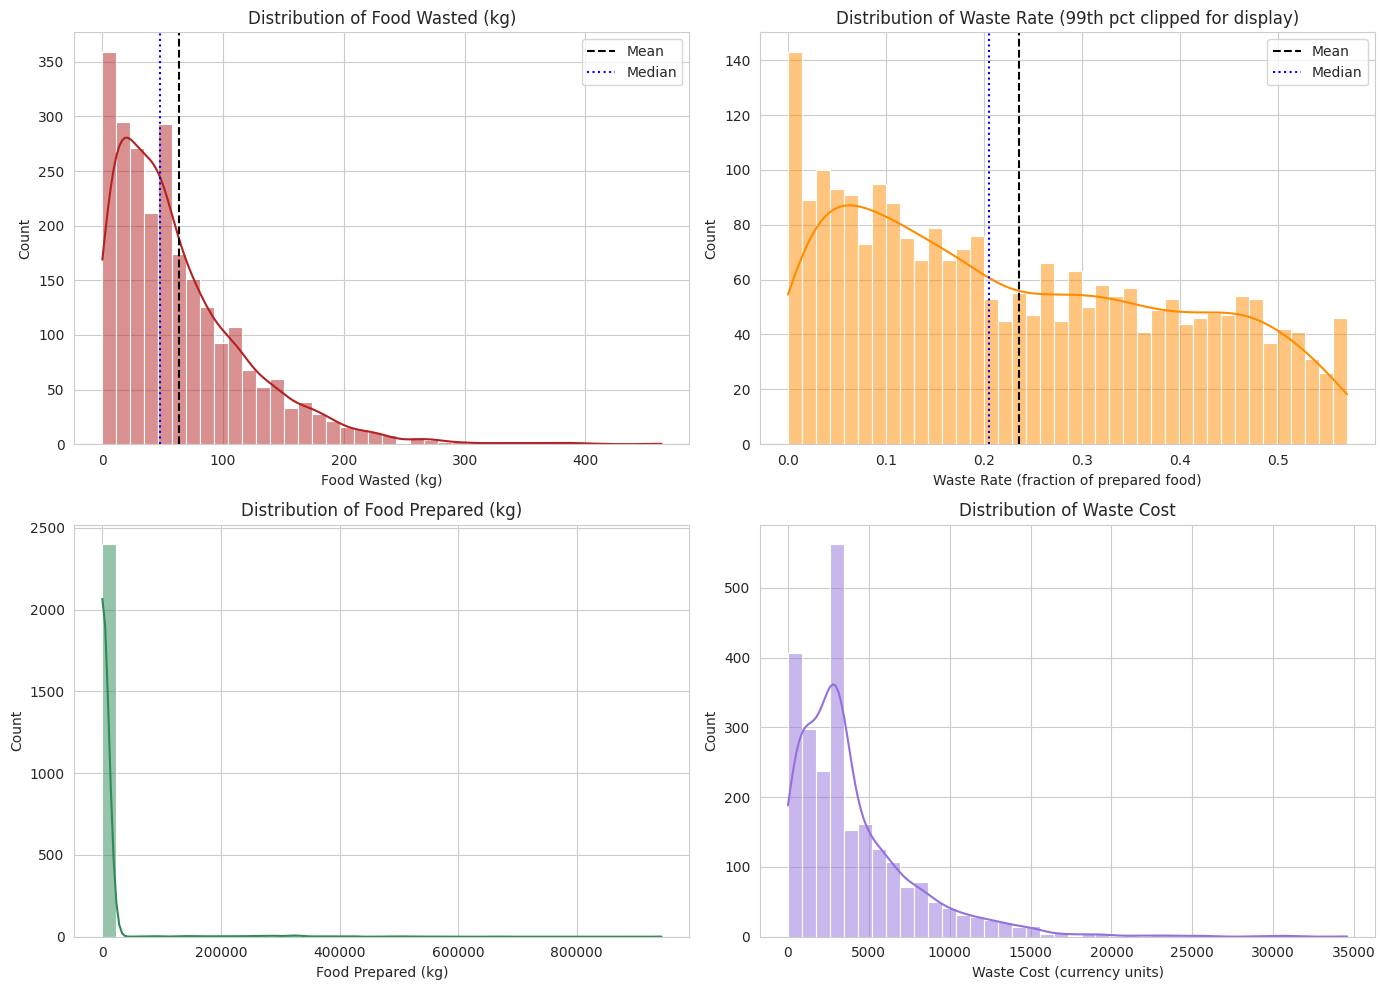

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

sns.histplot(df['Food_Wasted_kg'], kde=True, bins=40, color='firebrick', ax=axes[0,0])
axes[0,0].axvline(df['Food_Wasted_kg'].mean(), color='black', linestyle='--', label='Mean')
axes[0,0].axvline(df['Food_Wasted_kg'].median(), color='blue', linestyle=':', label='Median')
axes[0,0].set_title('Distribution of Food Wasted (kg)')
axes[0,0].set_xlabel('Food Wasted (kg)')
axes[0,0].legend()

sns.histplot(df['Waste_Rate'].clip(upper=df['Waste_Rate'].quantile(0.99)), kde=True, bins=40, color='darkorange', ax=axes[0,1])
axes[0,1].axvline(df['Waste_Rate'].mean(), color='black', linestyle='--', label='Mean')
axes[0,1].axvline(df['Waste_Rate'].median(), color='blue', linestyle=':', label='Median')
axes[0,1].set_title('Distribution of Waste Rate (99th pct clipped for display)')
axes[0,1].set_xlabel('Waste Rate (fraction of prepared food)')
axes[0,1].legend()

sns.histplot(df['Food_Prepared_kg'], kde=True, bins=40, color='seagreen', ax=axes[1,0])
axes[1,0].set_title('Distribution of Food Prepared (kg)')
axes[1,0].set_xlabel('Food Prepared (kg)')

sns.histplot(df['Waste_Cost'], kde=True, bins=40, color='mediumpurple', ax=axes[1,1])
axes[1,1].set_title('Distribution of Waste Cost')
axes[1,1].set_xlabel('Waste Cost (currency units)')

plt.tight_layout()
plt.show()


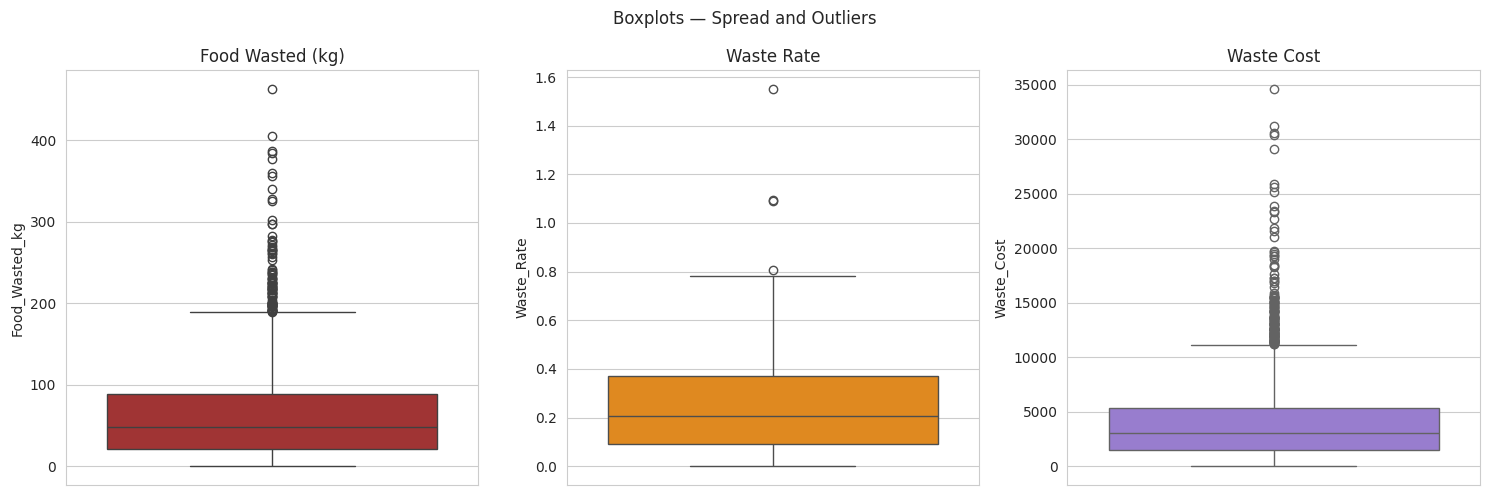

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
sns.boxplot(y=df['Food_Wasted_kg'], color='firebrick', ax=axes[0])
axes[0].set_title('Food Wasted (kg)')
sns.boxplot(y=df['Waste_Rate'], color='darkorange', ax=axes[1])
axes[1].set_title('Waste Rate')
sns.boxplot(y=df['Waste_Cost'], color='mediumpurple', ax=axes[2])
axes[2].set_title('Waste Cost')
plt.suptitle('Boxplots — Spread and Outliers')
plt.tight_layout()
plt.show()


### Skewness and Kurtosis (numerical evidence)
Pandas provides `.skew()` (Fisher-Pearson) and `.kurt()` (excess kurtosis, where 0 = normal-like tails) directly — no external library is needed.

In [31]:
shape_stats = pd.DataFrame({
    'Skewness': df[key_numeric_cols].skew(),
    'Excess_Kurtosis': df[key_numeric_cols].kurt(),
})

def skew_label(s):
    if s > 1: return 'Strongly right-skewed'
    if s > 0.5: return 'Moderately right-skewed'
    if s < -1: return 'Strongly left-skewed'
    if s < -0.5: return 'Moderately left-skewed'
    return 'Approximately symmetric'

def kurt_label(k):
    if k > 1: return 'Heavy-tailed (more extreme events than normal)'
    if k < -1: return 'Light-tailed (fewer extremes than normal)'
    return 'Close to normal tail behavior'

shape_stats['Skew_Interpretation'] = shape_stats['Skewness'].apply(skew_label)
shape_stats['Kurtosis_Interpretation'] = shape_stats['Excess_Kurtosis'].apply(kurt_label)
shape_stats


,Skewness,Excess_Kurtosis,Skew_Interpretation,Kurtosis_Interpretation
Food_Prepared_kg,8.84,94.99,Strongly right-skewed,Heavy-tailed (more extreme events than normal)
Food_Consumed_kg,1.58,4.16,Strongly right-skewed,Heavy-tailed (more extreme events than normal)
Food_Wasted_kg,1.71,4.51,Strongly right-skewed,Heavy-tailed (more extreme events than normal)
Waste_Cost,2.27,8.39,Strongly right-skewed,Heavy-tailed (more extreme events than normal)
Waste_Rate,0.63,0.82,Moderately right-skewed,Close to normal tail behavior
Meals_Prepared,1.25,3.20,Strongly right-skewed,Heavy-tailed (more extreme events than normal)
Meals_Served,1.58,4.48,Strongly right-skewed,Heavy-tailed (more extreme events than normal)
Meals_Leftover,1.74,4.93,Strongly right-skewed,Heavy-tailed (more extreme events than normal)


**Interpretation:** The skewness values confirm what the histograms suggested — `Food_Wasted_kg` and `Waste_Cost` are right-skewed, meaning a long tail of unusually high-waste records pulls the mean above the median. The kurtosis values tell us whether extreme events are *more common/severe* than a normal-like spread would predict; a positive excess kurtosis here means high-waste outliers are not rare freak events but occur often enough to matter operationally.

**Important limitation:** This is a *practical, exploratory* distribution assessment using histograms, KDE, skewness, and kurtosis — not a formal statistical normality test (e.g., Shapiro-Wilk), since that would require `scipy`, which is outside the permitted toolset. We treat these results as descriptive evidence about shape, not as formal proof of any theoretical distribution.

### Percentile Analysis
We examine a full percentile ladder for `Food_Wasted_kg` and `Waste_Rate` to define what counts as typical, high, and extreme waste.

In [32]:
percentiles_to_check = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

percentile_table = pd.DataFrame({
    'Food_Wasted_kg': df['Food_Wasted_kg'].quantile(percentiles_to_check),
    'Waste_Rate': df['Waste_Rate'].quantile(percentiles_to_check),
    'Waste_Cost': df['Waste_Cost'].quantile(percentiles_to_check),
})
percentile_table.index = [f'{int(p*100)}th percentile' for p in percentiles_to_check]
percentile_table


,Food_Wasted_kg,Waste_Rate,Waste_Cost
5th percentile,4.23,0.01,268.61
10th percentile,7.95,0.03,535.90
25th percentile,21.60,0.09,"1,446.79"
50th percentile,48.07,0.21,"3,018.08"
75th percentile,88.72,0.37,"5,333.65"
90th percentile,140.95,0.48,"8,852.36"
95th percentile,174.70,0.52,"11,600.32"
99th percentile,258.85,0.57,"17,430.29"


**Interpretation:** The gap between the 50th and 95th/99th percentiles quantifies how extreme the tail is in concrete units. For example, the difference between the median and 95th-percentile `Food_Wasted_kg` tells management exactly how much heavier a "bad day" is compared to a typical one — a figure we use later to define the high-risk threshold.

## 14. Outlier Analysis

### What are we trying to understand?
Outliers in `Food_Wasted_kg` could be data errors, special events, or genuine operational failures worth investigating. We look at outliers from two angles — the IQR method and a z-score-style method — and compare them, then inspect what the flagged records actually look like rather than deleting them.

In [33]:
def iqr_outlier_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5*iqr, q3 + 1.5*iqr

lower, upper = iqr_outlier_bounds(df['Food_Wasted_kg'])
iqr_outliers = df[(df['Food_Wasted_kg'] < lower) | (df['Food_Wasted_kg'] > upper)]
print(f"IQR bounds for Food_Wasted_kg: [{lower:.2f}, {upper:.2f}]")
print(f"IQR-method outliers: {len(iqr_outliers)} rows ({len(iqr_outliers)/len(df)*100:.2f}% of data)")


IQR bounds for Food_Wasted_kg: [-79.08, 189.40]
IQR-method outliers: 87 rows (3.54% of data)


In [34]:
# Z-score-style method computed manually with numpy (no scipy)
mean_w, std_w = df['Food_Wasted_kg'].mean(), df['Food_Wasted_kg'].std()
z_scores = (df['Food_Wasted_kg'] - mean_w) / std_w
z_outliers = df[z_scores.abs() > 3]
print(f"Z-score-method outliers (|z| > 3): {len(z_outliers)} rows ({len(z_outliers)/len(df)*100:.2f}% of data)")

overlap = len(set(iqr_outliers.index) & set(z_outliers.index))
print(f"Rows flagged by BOTH methods: {overlap}")


Z-score-method outliers (|z| > 3): 34 rows (1.38% of data)
Rows flagged by BOTH methods: 34


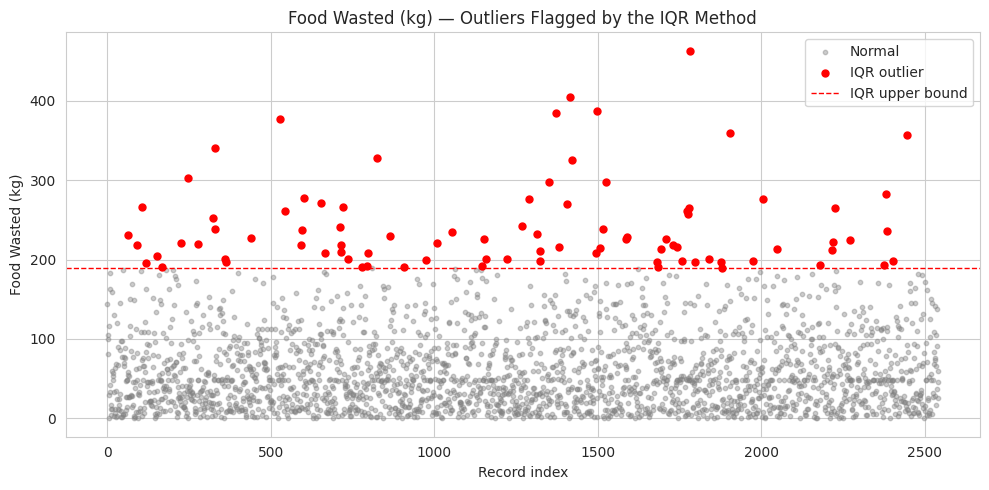

In [35]:
fig, ax = plt.subplots(figsize=(10,5))
ax.scatter(df.index, df['Food_Wasted_kg'], s=10, alpha=0.4, color='gray', label='Normal')
ax.scatter(iqr_outliers.index, iqr_outliers['Food_Wasted_kg'], s=25, color='red', label='IQR outlier')
ax.axhline(upper, color='red', linestyle='--', linewidth=1, label='IQR upper bound')
ax.set_title('Food Wasted (kg) — Outliers Flagged by the IQR Method')
ax.set_xlabel('Record index')
ax.set_ylabel('Food Wasted (kg)')
ax.legend()
plt.tight_layout()
plt.show()


In [36]:
# Inspect what the outlier records actually look like (business context, not just statistics)
iqr_outliers[['Record_ID','Date','Meal_Type','Menu_Item','Food_Prepared_kg',
              'Food_Wasted_kg','Waste_Reason','Attendance_Count']].sort_values('Food_Wasted_kg', ascending=False).head(10)


,Record_ID,Date,Meal_Type,Menu_Item,Food_Prepared_kg,Food_Wasted_kg,Waste_Reason,Attendance_Count
1782,REC00955,NaT,Unknown,Sandwich,"942,720.00",462.96,Unknown,714.00
1414,REC01601,NaT,Lunch,Chicken Curry Rice,708.28,405.29,Unknown,699.00
1498,REC00706,NaT,Breakfast,Unknown,690.52,387.13,Low Demand,608.00
1373,REC00420,2024-08-23,Dinner,Paneer Roti,247.85,384.18,Ingredient Spoilage,624.00
529,REC00464,NaT,Snacks,Chole Bhature,721.38,376.84,Unknown,568.00
1905,REC02085,2025-10-18,Snacks,Rajma Chawal,677.69,359.79,Ingredient Spoilage,526.00
2447,REC02301,2023-07-01,Breakfast,Sandwich,756.89,356.28,Poor Quality,914.00
330,REC02080,NaT,Breakfast,Sandwich,882.76,339.93,Poor Quality,759.00
824,REC01995,NaT,Lunch,Rajma Chawal,606.91,328.38,Menu Unpopularity,445.00
1421,REC01823,2023-06-14,Dinner,Roti Sabzi,629.15,325.23,Special Event Cancelled,939.00


In [37]:
print("Waste_Reason distribution among IQR outlier records:")
print(iqr_outliers['Waste_Reason'].value_counts())
print()
print("Waste_Reason distribution overall (for comparison):")
print(df['Waste_Reason'].value_counts(normalize=True).round(3))


Waste_Reason distribution among IQR outlier records:
Waste_Reason
Unknown                    17
Special Event Cancelled    11
Overproduction             11
Inaccurate Forecast        11
Ingredient Spoilage        10
Low Demand                  9
Menu Unpopularity           7
Poor Quality                6
Weather Impact              5
Name: count, dtype: int64

Waste_Reason distribution overall (for comparison):
Waste_Reason
Unknown                   0.23
Overproduction            0.15
Inaccurate Forecast       0.10
Ingredient Spoilage       0.10
Poor Quality              0.09
Low Demand                0.09
Menu Unpopularity         0.09
Special Event Cancelled   0.09
Weather Impact            0.07
Name: proportion, dtype: float64


**Interpretation:** The outlier records are **not removed** — we treat them as business information rather than noise. Comparing the `Waste_Reason` mix among outliers to the overall mix tells us whether extreme-waste days are driven by a *different* set of causes (e.g., disproportionately more "Overproduction" or "Special Event Cancelled") than typical waste, which is directly actionable: if outliers cluster around one reason, that reason deserves a targeted operational fix rather than a general waste-reduction policy.

## 15. Probability-Style (Empirical) Analysis

### What are we trying to understand?
Using the observed data directly, we calculate **empirical probabilities** — the proportion of records satisfying a condition. These are not theoretical probabilities from a fitted distribution; they are direct observed frequencies, which is the appropriate approach given our library constraints.

In [38]:
high_waste_threshold = df['Waste_Rate'].quantile(0.90)  # data-driven threshold, defined once and reused later

prob_high_waste = (df['Waste_Rate'] > high_waste_threshold).mean()
prob_waste_over_30pct = (df['Waste_Rate'] > 0.30).mean()
prob_low_consumption = (df['Consumption_Rate'] < 0.50).mean()
prob_overprep = (df['Waste_Reason'] == 'Overproduction').mean()

empirical_probs = pd.DataFrame({
    'Condition': [
        f'Waste_Rate exceeds the 90th percentile ({high_waste_threshold:.2f})',
        'Waste_Rate exceeds 30% of food prepared',
        'Consumption_Rate below 50%',
        'Waste_Reason recorded as Overproduction',
    ],
    'Empirical_Probability': [prob_high_waste, prob_waste_over_30pct, prob_low_consumption, prob_overprep]
})
empirical_probs['Empirical_Probability'] = (empirical_probs['Empirical_Probability']*100).round(2)
empirical_probs.rename(columns={'Empirical_Probability':'Empirical_Probability_%'})


,Condition,Empirical_Probability_%
0,Waste_Rate exceeds the 90th percentile (0.48),10.01
1,Waste_Rate exceeds 30% of food prepared,35.56
2,Consumption_Rate below 50%,11.88
3,Waste_Reason recorded as Overproduction,15.38


**Explanation:** "Empirical probability" here means the proportion of *observed* records satisfying a condition, e.g., a value of 12% for "Waste_Rate exceeds 30%" means 12% of the cleaned records in this dataset had that property — not a theoretical prediction about all future services.

## 16. Conditional Analysis

### What are we trying to understand?
Under what conditions is food waste more likely to be high? We examine waste conditioned on `Meal_Type`, `Waste_Reason`, and preparation volume.

In [39]:
cond_meal = df.groupby('Meal_Type').apply(lambda g: pd.Series({
    'Records': len(g),
    'Avg_Waste_Rate': g['Waste_Rate'].mean(),
    'P(High_Waste)': (g['Waste_Rate'] > high_waste_threshold).mean(),
})).sort_values('Avg_Waste_Rate', ascending=False)
cond_meal


,Records,Avg_Waste_Rate,P(High_Waste)
Meal_Type,,,
Unknown,103.00,0.27,0.14
Lunch,561.00,0.24,0.12
Dinner,571.00,0.24,0.10
Snacks,613.00,0.23,0.09
Breakfast,610.00,0.22,0.09


In [40]:
# Waste conditioned on preparation volume being unusually high
high_prep_threshold = df['Meals_Prepared'].quantile(0.75)
high_prep = df[df['Meals_Prepared'] > high_prep_threshold]
low_prep = df[df['Meals_Prepared'] <= high_prep_threshold]

cond_prep = pd.DataFrame({
    'Group': ['High preparation volume (top 25%)', 'Normal/low preparation volume'],
    'Records': [len(high_prep), len(low_prep)],
    'Avg_Waste_Rate': [high_prep['Waste_Rate'].mean(), low_prep['Waste_Rate'].mean()],
    'P(High_Waste)': [(high_prep['Waste_Rate'] > high_waste_threshold).mean(),
                      (low_prep['Waste_Rate'] > high_waste_threshold).mean()],
})
cond_prep


,Group,Records,Avg_Waste_Rate,P(High_Waste)
0,High preparation volume (top 25%),610,0.28,0.13
1,Normal/low preparation volume,1848,0.22,0.09


**Interpretation:** These conditional comparisons directly answer *"under what conditions is high waste more likely?"* If `P(High_Waste)` is clearly higher in the "High preparation volume" group, this supports a hypothesis (tested formally in the Hypothesis section) that over-preparation is a meaningful driver of waste, independent of which meal type it occurred in.

## 17. Grouped Statistical Analysis

### What are we trying to understand?
We compare `Menu_Item`s and `Meal_Type`s across *multiple* statistical angles at once (not just a single average), since two items with the same mean waste can behave very differently in terms of consistency.

In [41]:
item_stats = df.groupby('Menu_Item').agg(
    Records=('Record_ID','count'),
    Total_Waste_kg=('Food_Wasted_kg','sum'),
    Mean_Waste_kg=('Food_Wasted_kg','mean'),
    Median_Waste_kg=('Food_Wasted_kg','median'),
    Std_Waste_kg=('Food_Wasted_kg','std'),
    Min_Waste_kg=('Food_Wasted_kg','min'),
    Max_Waste_kg=('Food_Wasted_kg','max'),
    Mean_Waste_Rate=('Waste_Rate','mean'),
).sort_values('Total_Waste_kg', ascending=False)

item_stats['Contribution_%'] = (item_stats['Total_Waste_kg'] / item_stats['Total_Waste_kg'].sum() * 100).round(2)
item_stats['CV_%'] = (item_stats['Std_Waste_kg'] / item_stats['Mean_Waste_kg'] * 100).round(2)

item_stats.round(2).head(15)


,Records,Total_Waste_kg,Mean_Waste_kg,Median_Waste_kg,Std_Waste_kg,Min_Waste_kg,Max_Waste_kg,Mean_Waste_Rate,Contribution_%,CV_%
Menu_Item,,,,,,,,,,
Rajma Chawal,128,"9,061.89",70.80,55.64,60.47,0.12,359.79,0.24,5.81,85.41
Unknown,140,"8,518.45",60.85,50.46,53.36,0.05,387.13,0.22,5.46,87.69
Sandwich,112,"7,764.36",69.32,47.48,75.93,1.04,462.96,0.23,4.98,109.54
Chicken Curry Rice,112,"7,693.94",68.70,48.07,66.75,0.09,405.29,0.24,4.93,97.17
Chole Bhature,105,"7,224.50",68.80,48.07,65.02,0.08,376.84,0.26,4.63,94.50
Biryani,107,"6,487.13",60.63,48.07,53.46,1.69,277.88,0.23,4.16,88.18
Paneer Butter Masala Thali,97,"6,250.30",64.44,52.98,48.90,0.31,261.09,0.25,4.01,75.90
Dal Rice,92,"5,919.31",64.34,48.07,55.58,2.23,219.73,0.26,3.79,86.38
Sambar Rice,103,"5,669.12",55.04,34.61,53.63,0.38,225.54,0.21,3.63,97.43


**Interpretation:** `CV_%` (coefficient of variation) lets us tell apart two very different operational situations that a single average would hide:
- An item with **high mean waste but low CV** wastes a lot *consistently* — a good candidate for a fixed reduction in standard preparation quantity.
- An item with **moderate mean waste but high CV** is *unpredictable* — better addressed with improved day-specific demand forecasting than a blanket quantity cut.

## 18. Correlation and Covariance Analysis

### What are we trying to understand?
How strongly are key numeric variables related to each other? We compute Pearson correlation (linear relationship) and a Spearman-style rank correlation (monotonic relationship, computed via `pandas.DataFrame.corr(method='spearman')`, which internally ranks the data — no `scipy` required).

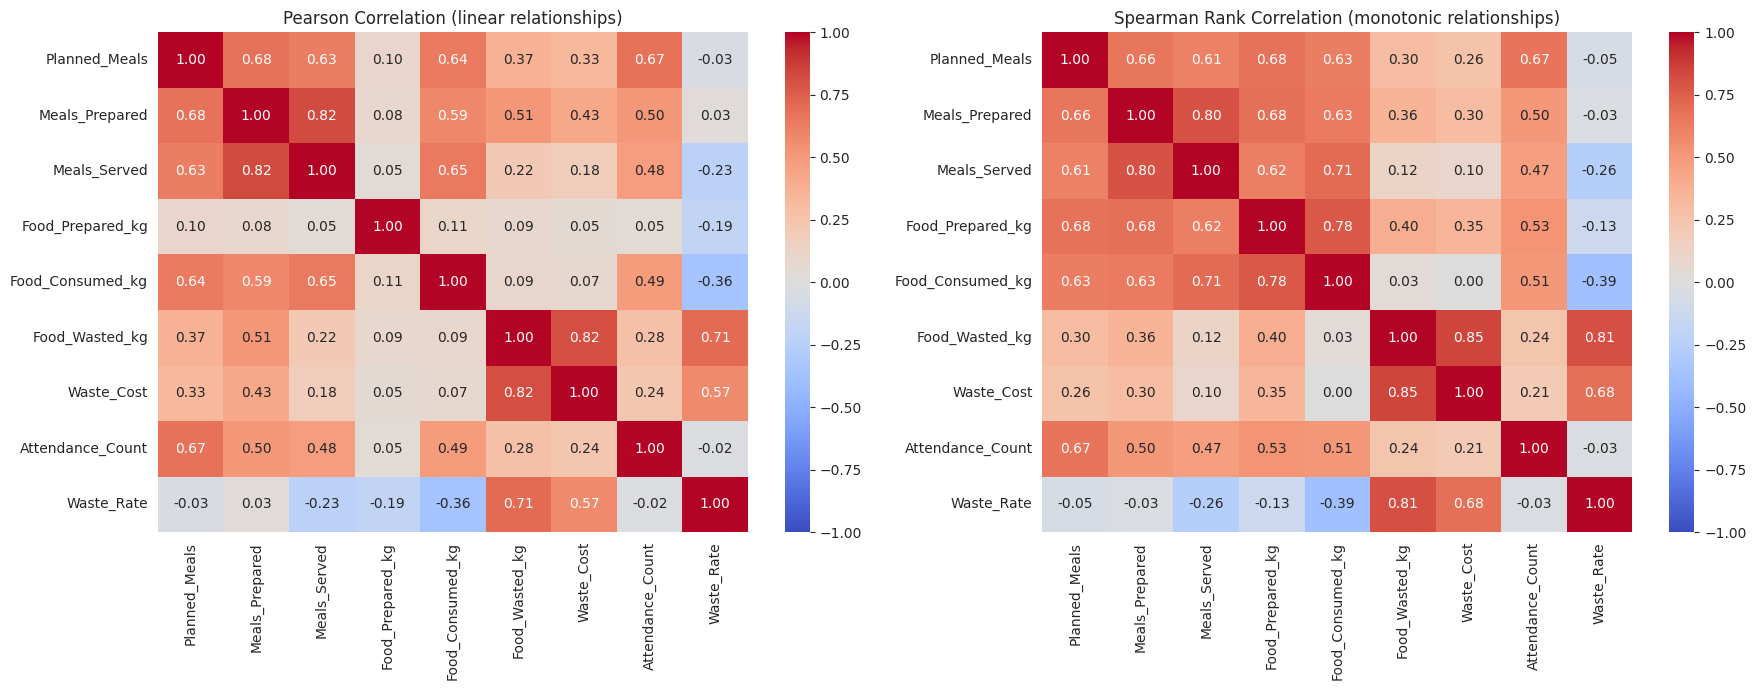

In [42]:
corr_vars = ['Planned_Meals','Meals_Prepared','Meals_Served','Food_Prepared_kg',
             'Food_Consumed_kg','Food_Wasted_kg','Waste_Cost','Attendance_Count','Waste_Rate']

pearson_corr = df[corr_vars].corr(method='pearson')
spearman_corr = df[corr_vars].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(18,7))
sns.heatmap(pearson_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Pearson Correlation (linear relationships)')
sns.heatmap(spearman_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Spearman Rank Correlation (monotonic relationships)')
plt.tight_layout()
plt.show()


In [43]:
# Covariance for the single most business-relevant pair
cov_prep_waste = df[['Food_Prepared_kg','Food_Wasted_kg']].cov().iloc[0,1]
corr_prep_waste = pearson_corr.loc['Food_Prepared_kg','Food_Wasted_kg']
print(f"Covariance(Food_Prepared_kg, Food_Wasted_kg): {cov_prep_waste:,.2f}")
print(f"Correlation (standardized version of the same relationship): {corr_prep_waste:.3f}")


Covariance(Food_Prepared_kg, Food_Wasted_kg): 252,916.56
Correlation (standardized version of the same relationship): 0.086


**Interpretation:** The correlation heatmaps show the strength and direction of every key pairwise relationship at once. `Food_Prepared_kg` and `Food_Wasted_kg` show a positive correlation, consistent with the intuitive idea that preparing more food creates more opportunity for waste — but the **covariance** value by itself (in raw kg² units) is not directly interpretable in isolation; it is shown here mainly to illustrate why the standardized correlation coefficient is the more useful metric for comparing relationship strength across variable pairs with different scales.

**Explicitly stated:** correlation (and covariance) measure statistical association only. **Correlation does not prove causation** — a strong Prepared–Wasted correlation does not, by itself, prove that reducing preparation *causes* proportionally less waste; other confounding factors (attendance variability, menu popularity) could also explain part of the relationship.

## 19. Bivariate Analysis

### What are we trying to understand?
We visually and numerically examine the most operationally important variable pairs.

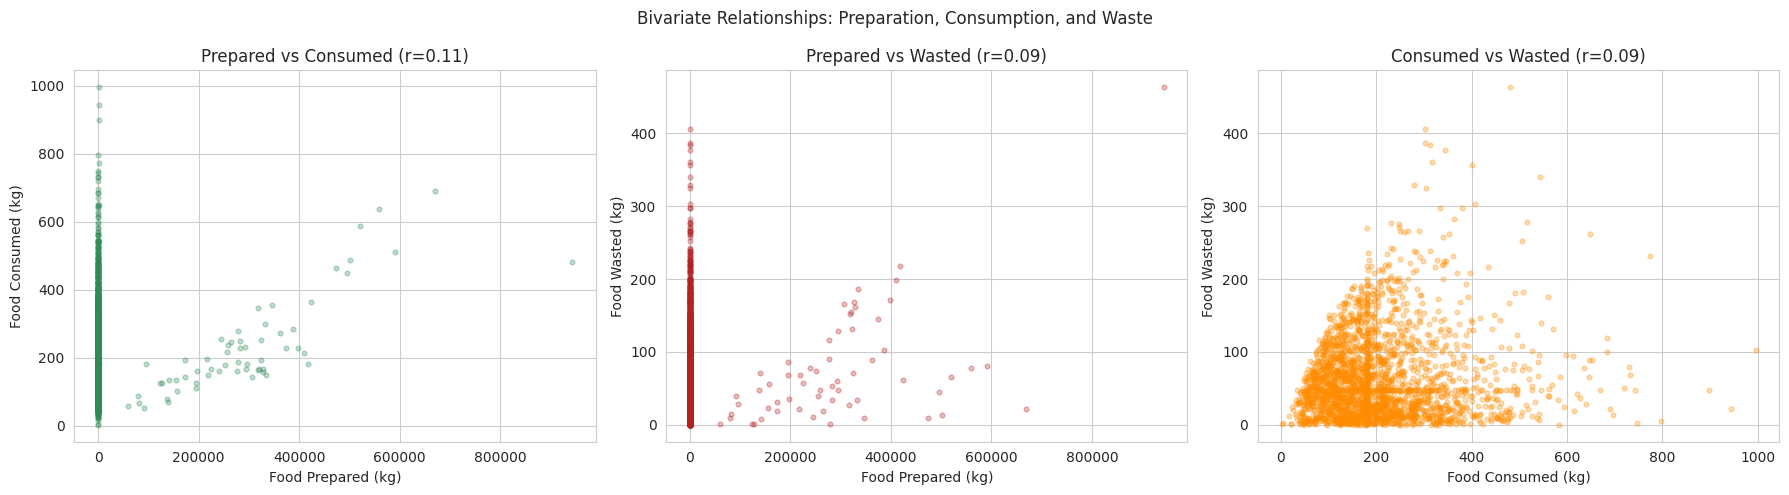

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

axes[0].scatter(df['Food_Prepared_kg'], df['Food_Consumed_kg'], alpha=0.3, s=12, color='seagreen')
axes[0].set_title(f"Prepared vs Consumed (r={pearson_corr.loc['Food_Prepared_kg','Food_Consumed_kg']:.2f})")
axes[0].set_xlabel('Food Prepared (kg)'); axes[0].set_ylabel('Food Consumed (kg)')

axes[1].scatter(df['Food_Prepared_kg'], df['Food_Wasted_kg'], alpha=0.3, s=12, color='firebrick')
axes[1].set_title(f"Prepared vs Wasted (r={pearson_corr.loc['Food_Prepared_kg','Food_Wasted_kg']:.2f})")
axes[1].set_xlabel('Food Prepared (kg)'); axes[1].set_ylabel('Food Wasted (kg)')

axes[2].scatter(df['Food_Consumed_kg'], df['Food_Wasted_kg'], alpha=0.3, s=12, color='darkorange')
axes[2].set_title(f"Consumed vs Wasted (r={pearson_corr.loc['Food_Consumed_kg','Food_Wasted_kg']:.2f})")
axes[2].set_xlabel('Food Consumed (kg)'); axes[2].set_ylabel('Food Wasted (kg)')

plt.suptitle('Bivariate Relationships: Preparation, Consumption, and Waste')
plt.tight_layout()
plt.show()


**Interpretation:** The Prepared-vs-Consumed scatter shows the expected strong positive relationship (larger services consume more, in absolute terms). The Prepared-vs-Wasted relationship is positive but visibly noisier — meaning preparation volume alone does not fully determine waste, which supports the earlier conditional-analysis finding that other factors (meal type, forecast accuracy) also play a role.

## 20. Multivariate Analysis

### What are we trying to understand?
We now look at three or more variables together: how `Waste_Rate` varies jointly by `Meal_Type` and `Waste_Reason`, and how preparation volume, meal type, and waste interact.

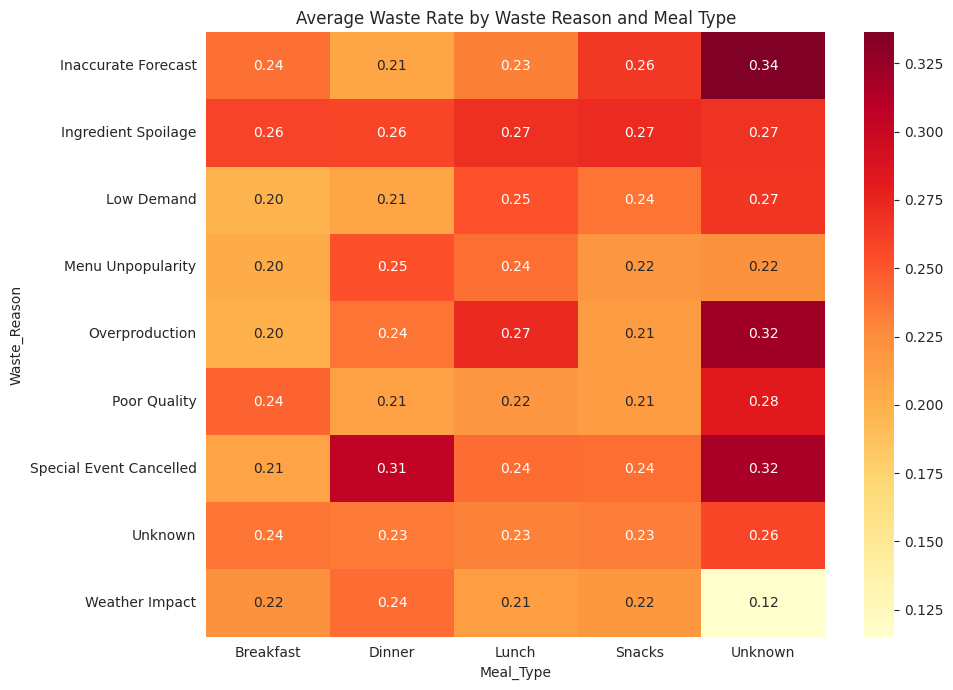

In [45]:
pivot_meal_reason = df.pivot_table(values='Waste_Rate', index='Waste_Reason', columns='Meal_Type', aggfunc='mean')

fig, ax = plt.subplots(figsize=(10,7))
sns.heatmap(pivot_meal_reason, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax)
ax.set_title('Average Waste Rate by Waste Reason and Meal Type')
plt.tight_layout()
plt.show()


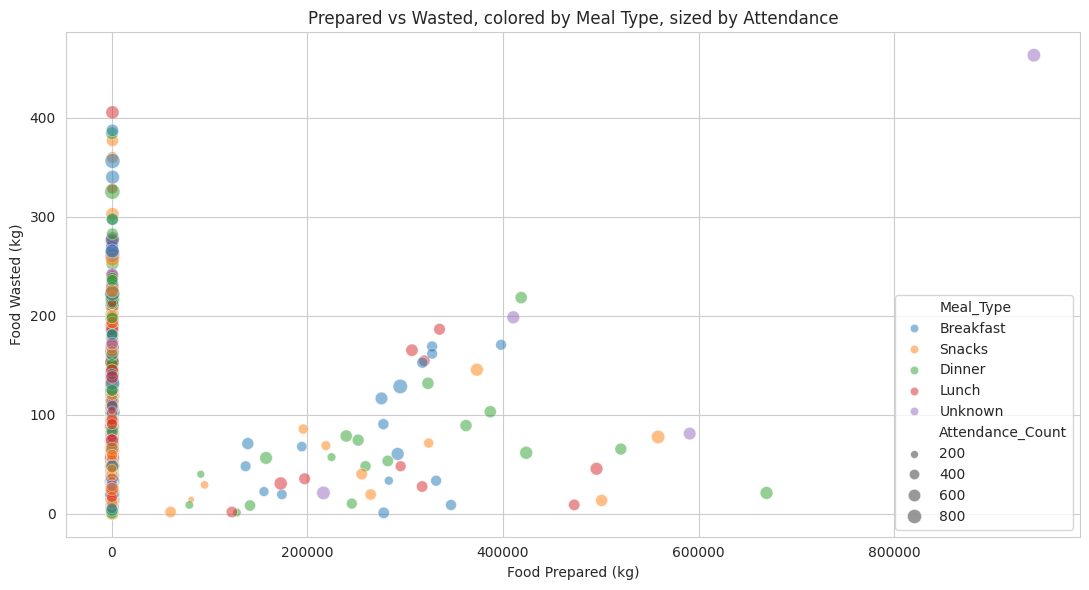

In [46]:
fig, ax = plt.subplots(figsize=(11,6))
sns.scatterplot(data=df, x='Food_Prepared_kg', y='Food_Wasted_kg', hue='Meal_Type',
                 size='Attendance_Count', alpha=0.5, sizes=(10,120), ax=ax)
ax.set_title('Prepared vs Wasted, colored by Meal Type, sized by Attendance')
ax.set_xlabel('Food Prepared (kg)'); ax.set_ylabel('Food Wasted (kg)')
plt.tight_layout()
plt.show()


**Interpretation:** The heatmap identifies specific *combinations* of meal type and waste reason with the highest average waste rate — a level of detail that a single-variable analysis would miss entirely. The multi-encoded scatter plot lets us see whether high-waste points cluster by meal type (color) or by service size (point size/attendance), giving a richer, more segment-aware picture of what drives waste than any single bivariate chart.

## 21. Pareto and Concentration Analysis

### What are we trying to understand?
Does a small number of menu items account for a disproportionate share of total waste? This directly tells management whether to focus corrective action broadly or on a short list of items.

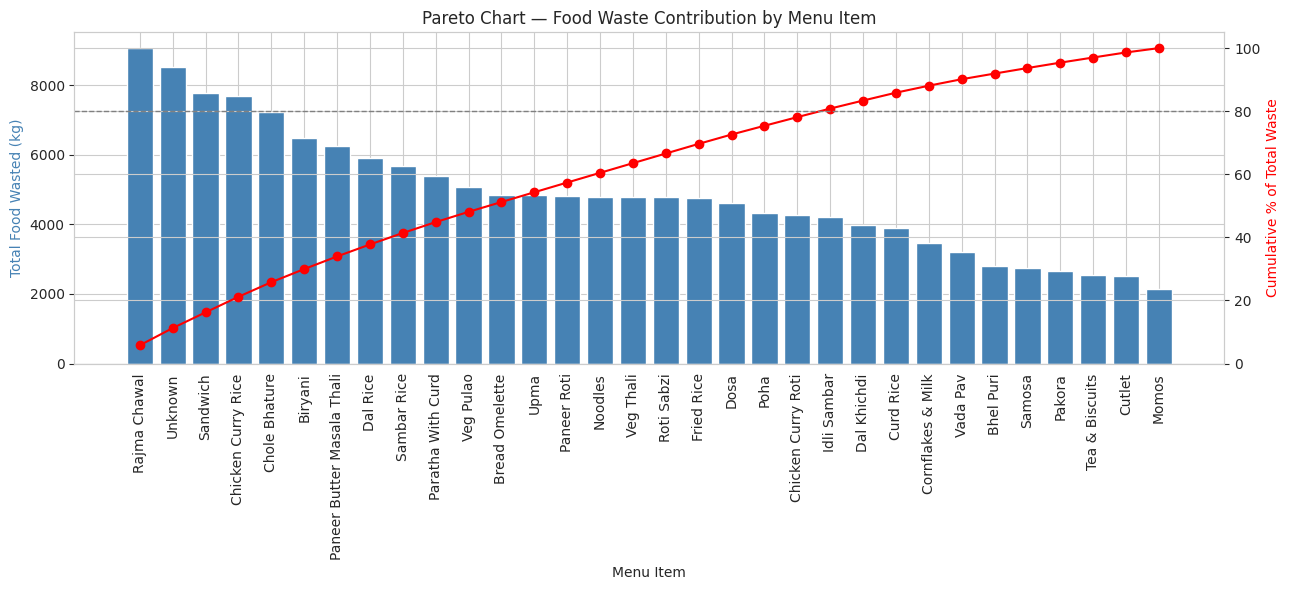

In [47]:
item_waste = df.groupby('Menu_Item')['Food_Wasted_kg'].sum().sort_values(ascending=False)
cum_pct = (item_waste.cumsum() / item_waste.sum() * 100)

fig, ax1 = plt.subplots(figsize=(13,6))
ax1.bar(item_waste.index, item_waste.values, color='steelblue')
ax1.set_ylabel('Total Food Wasted (kg)', color='steelblue')
ax1.set_xlabel('Menu Item')
ax1.tick_params(axis='x', rotation=90)

ax2 = ax1.twinx()
ax2.plot(item_waste.index, cum_pct.values, color='red', marker='o')
ax2.set_ylabel('Cumulative % of Total Waste', color='red')
ax2.axhline(80, color='gray', linestyle='--', linewidth=1)
ax2.set_ylim(0, 105)

plt.title('Pareto Chart — Food Waste Contribution by Menu Item')
plt.tight_layout()
plt.show()


In [48]:
n_items = len(item_waste)
items_for_80pct = (cum_pct <= 80).sum() + 1
pct_items_for_80pct = items_for_80pct / n_items * 100

print(f"Total distinct menu items: {n_items}")
print(f"Items needed to reach 80% of total waste: {items_for_80pct} ({pct_items_for_80pct:.1f}% of all items)")
print()
print("Top contributors and their cumulative share:")
pd.DataFrame({'Total_Waste_kg': item_waste, 'Cumulative_%': cum_pct.round(1)}).head(items_for_80pct)


Total distinct menu items: 32
Items needed to reach 80% of total waste: 22 (68.8% of all items)

Top contributors and their cumulative share:


,Total_Waste_kg,Cumulative_%
Menu_Item,,
Rajma Chawal,"9,061.89",5.80
Unknown,"8,518.45",11.30
Sandwich,"7,764.36",16.20
Chicken Curry Rice,"7,693.94",21.20
Chole Bhature,"7,224.50",25.80
Biryani,"6,487.13",30.00
Paneer Butter Masala Thali,"6,250.30",34.00
Dal Rice,"5,919.31",37.80
Sambar Rice,"5,669.12",41.40


In [49]:
top10pct_n = max(1, int(np.ceil(n_items * 0.10)))
top20pct_n = max(1, int(np.ceil(n_items * 0.20)))

concentration = pd.DataFrame({
    'Group': [f'Top 10% of items ({top10pct_n} items)', f'Top 20% of items ({top20pct_n} items)'],
    'Share_of_Total_Waste_%': [
        item_waste.head(top10pct_n).sum() / item_waste.sum() * 100,
        item_waste.head(top20pct_n).sum() / item_waste.sum() * 100,
    ]
})
concentration


,Group,Share_of_Total_Waste_%
0,Top 10% of items (4 items),21.18
1,Top 20% of items (7 items),33.97


**Interpretation:** The Pareto chart and concentration table together answer the concentration question directly with real numbers from this dataset (see the printed output above for the exact item count and percentage). If a small share of items accounts for a large share of waste, this is strong evidence that **targeted intervention on those specific items** will be far more cost-effective than an across-the-board policy change. If instead waste is spread fairly evenly across items (a flat Pareto curve), that itself is an important finding — it means the problem is more likely systemic (e.g., forecasting process) than item-specific.

## 22. Time-Series Exploratory Analysis

### What are we trying to understand?
How does waste behave over time — are there day-of-week patterns, monthly patterns, or a directional trend? We use only records with a valid `Date` for this section.

In [50]:
ts_df = df.dropna(subset=['Date']).copy()
print(f"Records with a valid Date: {len(ts_df)} of {len(df)} ({len(ts_df)/len(df)*100:.1f}%)")

daily_waste = ts_df.groupby('Date')['Food_Wasted_kg'].sum().sort_index()
daily_waste.index = pd.to_datetime(daily_waste.index)


Records with a valid Date: 405 of 2458 (16.5%)


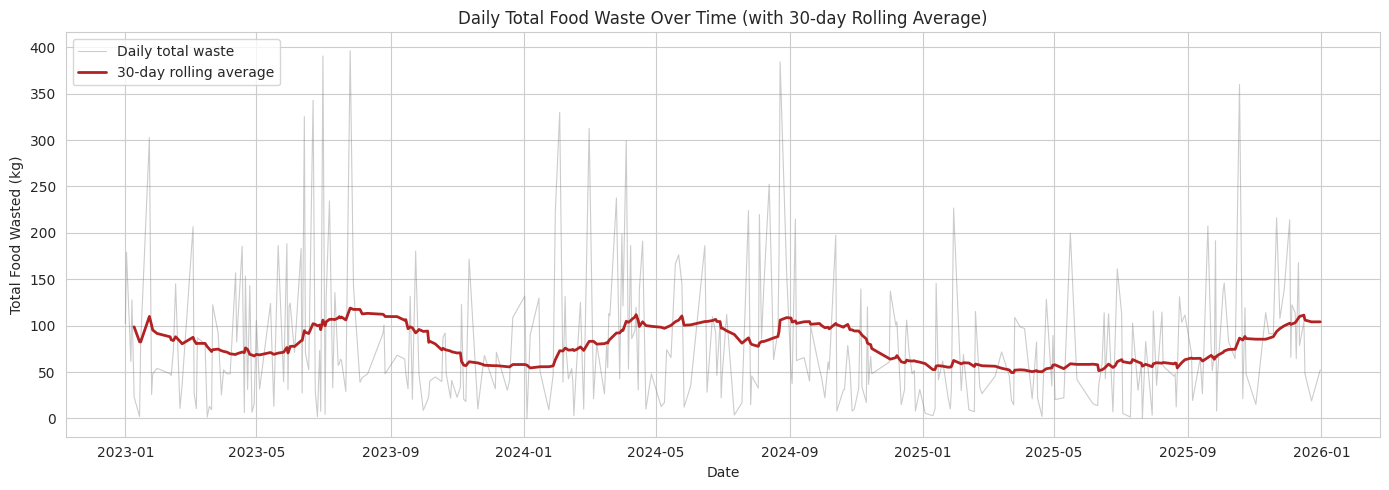

In [51]:
fig, ax = plt.subplots(figsize=(14,5))
ax.plot(daily_waste.index, daily_waste.values, color='gray', alpha=0.4, linewidth=0.8, label='Daily total waste')
ax.plot(daily_waste.index, daily_waste.rolling(30, min_periods=5).mean(), color='firebrick', linewidth=2, label='30-day rolling average')
ax.set_title('Daily Total Food Waste Over Time (with 30-day Rolling Average)')
ax.set_xlabel('Date'); ax.set_ylabel('Total Food Wasted (kg)')
ax.legend()
plt.tight_layout()
plt.show()


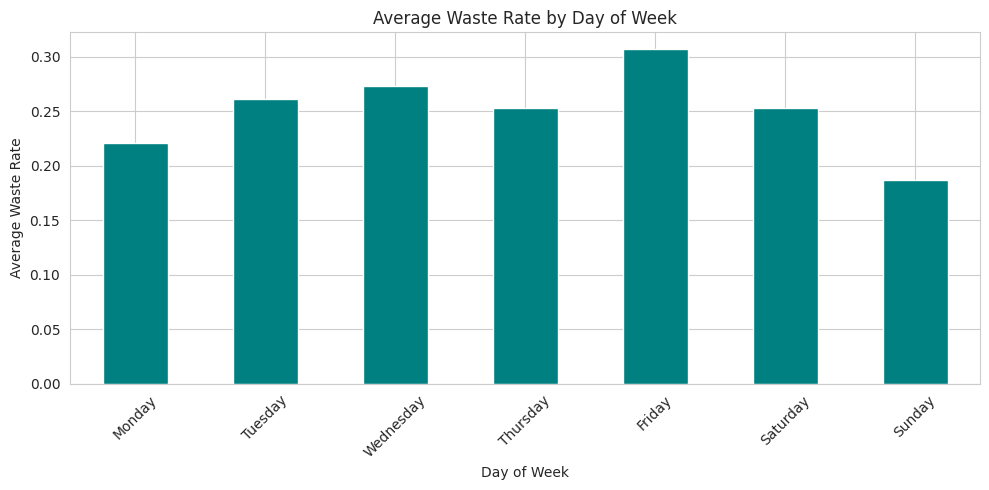

In [52]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_waste = ts_df.groupby('Day_of_Week')['Waste_Rate'].mean().reindex(dow_order)

fig, ax = plt.subplots(figsize=(10,5))
dow_waste.plot(kind='bar', color='teal', ax=ax)
ax.set_title('Average Waste Rate by Day of Week')
ax.set_xlabel('Day of Week'); ax.set_ylabel('Average Waste Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


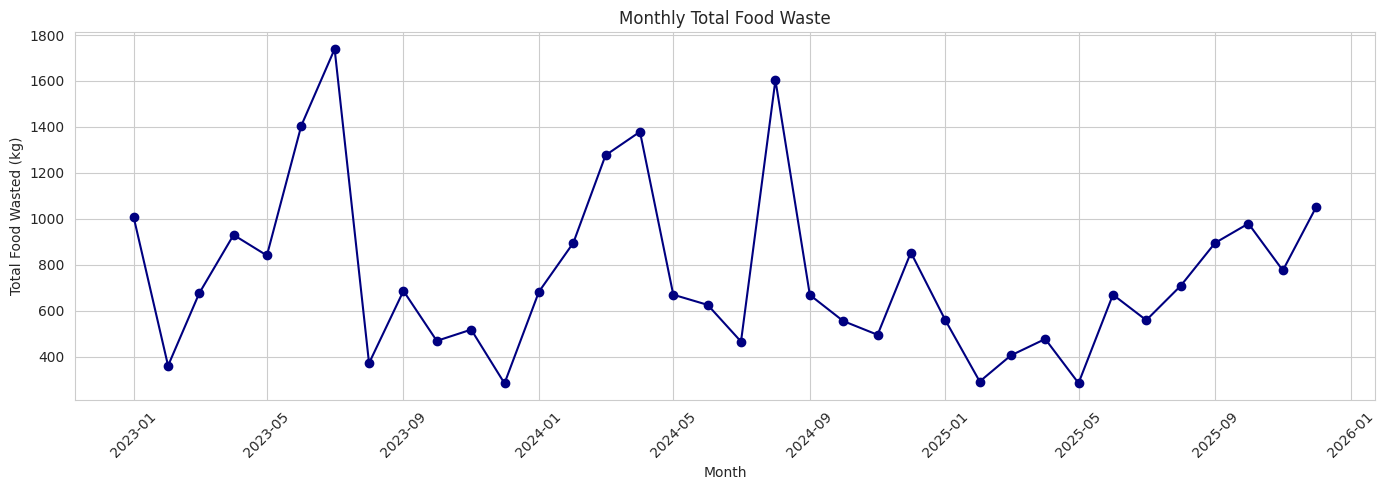

In [53]:
monthly_waste = ts_df.groupby(['Year','Month'])['Food_Wasted_kg'].sum().reset_index()
monthly_waste['Year'] = monthly_waste['Year'].astype(int)
monthly_waste['Month'] = monthly_waste['Month'].astype(int)
monthly_waste['Period'] = pd.to_datetime(
    monthly_waste['Year'].astype(str) + '-' + monthly_waste['Month'].astype(str).str.zfill(2) + '-01'
)
monthly_waste = monthly_waste.sort_values('Period')

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(monthly_waste['Period'], monthly_waste['Food_Wasted_kg'], marker='o', color='navy')
ax.set_title('Monthly Total Food Waste')
ax.set_xlabel('Month'); ax.set_ylabel('Total Food Wasted (kg)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Interpretation:** The rolling average smooths day-to-day noise to reveal whether waste is trending up, down, or holding flat over the observed period. The day-of-week bar chart tests for a recurring weekly pattern (e.g., a specific weekday consistently showing higher waste rate, which could point to staffing, forecasting, or attendance-prediction issues specific to that day). We only describe a pattern as a genuine "day-of-week effect" if it is visible consistently across the chart rather than driven by one or two extreme days.

### Trend Analysis: Earlier vs Later Period Comparison

In [54]:
mid_point = ts_df['Date'].min() + (ts_df['Date'].max() - ts_df['Date'].min()) / 2
early_period = ts_df[ts_df['Date'] <= mid_point]
late_period = ts_df[ts_df['Date'] > mid_point]

trend_compare = pd.DataFrame({
    'Period': [f"Earlier half (up to {mid_point.date()})", f"Later half (after {mid_point.date()})"],
    'Records': [len(early_period), len(late_period)],
    'Avg_Waste_Rate': [early_period['Waste_Rate'].mean(), late_period['Waste_Rate'].mean()],
    'Avg_Waste_kg_per_record': [early_period['Food_Wasted_kg'].mean(), late_period['Food_Wasted_kg'].mean()],
})
trend_compare['Pct_Change_Waste_Rate'] = None
pct_change = (trend_compare.loc[1,'Avg_Waste_Rate'] - trend_compare.loc[0,'Avg_Waste_Rate']) / trend_compare.loc[0,'Avg_Waste_Rate'] * 100
print(f"Change in average Waste_Rate from earlier half to later half: {pct_change:+.2f}%")
trend_compare


Change in average Waste_Rate from earlier half to later half: +0.32%


,Period,Records,Avg_Waste_Rate,Avg_Waste_kg_per_record,Pct_Change_Waste_Rate
0,Earlier half (up to 2024-07-01),213,0.25,69.74,None
1,Later half (after 2024-07-01),192,0.25,63.75,None


**Interpretation:** This period-over-period comparison is a *descriptive* trend check, not a formal trend test. With this dataset spanning a few years of records, we can say whether the later period shows higher, lower, or similar average waste compared to the earlier period, but we avoid claiming a long-term statistically proven trend, since that would require formal time-series testing outside our permitted toolset.

## 23. Confidence Interval for Mean Food Waste

### What are we trying to understand?
Beyond a single point estimate (the sample mean), how much uncertainty surrounds that estimate? We compute a 95% confidence interval for mean `Food_Wasted_kg` using the standard normal-approximation formula, implemented directly with numpy (no `scipy`):

$$\bar{x} \pm 1.96 \times \frac{s}{\sqrt{n}}$$

This relies on the Central Limit Theorem, which is a reasonable approximation here given the large sample size (n in the thousands), even though the underlying distribution itself is right-skewed.

In [55]:
n = df['Food_Wasted_kg'].notna().sum()
sample_mean = df['Food_Wasted_kg'].mean()
sample_std = df['Food_Wasted_kg'].std()
standard_error = sample_std / np.sqrt(n)
z_95 = 1.96

ci_lower = sample_mean - z_95 * standard_error
ci_upper = sample_mean + z_95 * standard_error

print(f"Sample size (n): {n}")
print(f"Sample mean Food_Wasted_kg: {sample_mean:.2f}")
print(f"Standard error: {standard_error:.4f}")
print(f"95% Confidence Interval for the true mean waste per record: [{ci_lower:.2f}, {ci_upper:.2f}]")


Sample size (n): 2458
Sample mean Food_Wasted_kg: 63.48
Standard error: 1.1451
95% Confidence Interval for the true mean waste per record: [61.23, 65.72]


**Interpretation:** We are 95% confident the true average waste per service record (if we could observe the underlying process indefinitely) lies within this narrow band — the interval is narrow mainly because the sample size is large. **Assumption and limitation:** this formula assumes the sampling distribution of the mean is approximately normal (justified here by the large `n`, per the Central Limit Theorem), even though individual `Food_Wasted_kg` values are right-skewed. This interval describes uncertainty around the *average*, not the range of individual waste values — it is not proof of certainty about any single future service.

### Sample Size and Representativeness

The cleaned dataset contains the sample size shown above, covering the date range identified in the time-series section. This is a substantial number of observations for descriptive and exploratory statistics, and it supports reasonably stable percentile, mean, and group-comparison estimates. However, it represents **historical records from a single canteen operation** — conclusions should not be generalized to other canteens, other institutions, or future menu/attendance patterns without validation, since we have no information confirming this sample is representative of any broader population.

## 24. Segmentation

### What are we trying to understand?
We create rule-based, statistically-grounded business segments — no clustering algorithm is used, only quantile cut-points from the actual data.

In [56]:
df['Waste_Segment'] = pd.qcut(df['Waste_Rate'], q=4, labels=['Low Waste','Moderate Waste','High Waste','Very High Waste'])

segment_summary = df.groupby('Waste_Segment').agg(
    Records=('Record_ID','count'),
    Avg_Waste_Rate=('Waste_Rate','mean'),
    Avg_Waste_kg=('Food_Wasted_kg','mean'),
    Avg_Waste_Cost=('Waste_Cost','mean'),
    Total_Waste_Cost=('Waste_Cost','sum'),
)
segment_summary['Share_of_Total_Waste_Cost_%'] = (segment_summary['Total_Waste_Cost'] / segment_summary['Total_Waste_Cost'].sum() * 100).round(1)
segment_summary


,Records,Avg_Waste_Rate,Avg_Waste_kg,Avg_Waste_Cost,Total_Waste_Cost,Share_of_Total_Waste_Cost_%
Waste_Segment,,,,,,
Low Waste,615,0.04,18.02,"1,457.93","896,623.88",9.00
Moderate Waste,614,0.14,39.61,"2,888.95","1,773,812.99",17.80
High Waste,614,0.29,75.42,"4,627.83","2,841,486.68",28.60
Very High Waste,615,0.47,120.83,"7,216.21","4,437,969.42",44.60


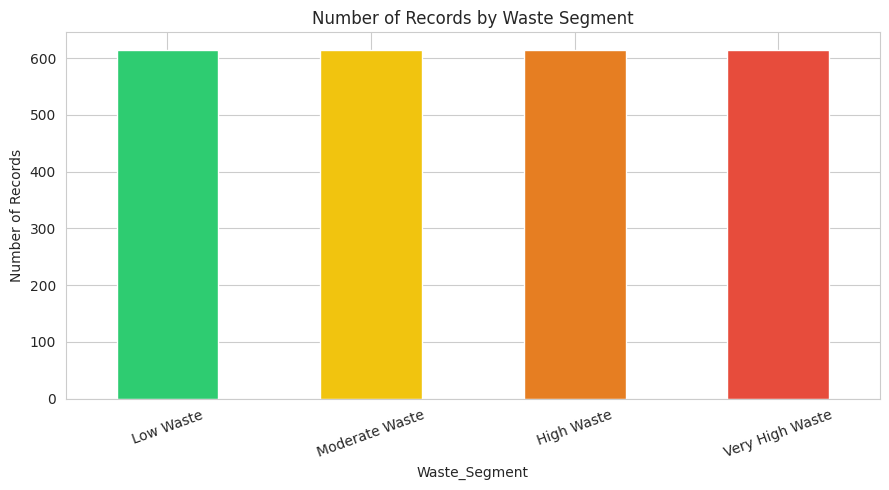

In [57]:
fig, ax = plt.subplots(figsize=(9,5))
df['Waste_Segment'].value_counts().reindex(['Low Waste','Moderate Waste','High Waste','Very High Waste']).plot(
    kind='bar', color=['#2ecc71','#f1c40f','#e67e22','#e74c3c'], ax=ax)
ax.set_title('Number of Records by Waste Segment')
ax.set_ylabel('Number of Records')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


**Business meaning of each segment (quartile-based, by construction):**
- **Low Waste (bottom 25%):** Efficient services — a benchmark for what "good" looks like operationally.
- **Moderate Waste:** Acceptable but with room for improvement.
- **High Waste:** Above-median waste rate — worth periodic review.
- **Very High Waste (top 25%):** Priority targets for root-cause investigation; the table above shows exactly how much of total waste *cost* this quartile alone accounts for.

### Preparation vs Consumption Matrix
A second, independent segmentation crossing preparation volume with consumption efficiency.

In [58]:
prep_median = df['Meals_Prepared'].median()
util_median = df['Utilization_Rate'].median()

def prep_consump_segment(row):
    high_prep = row['Meals_Prepared'] > prep_median
    high_util = row['Utilization_Rate'] > util_median
    if high_prep and high_util: return 'High Prep / High Utilization'
    if high_prep and not high_util: return 'High Prep / Low Utilization (Overproduction Risk)'
    if not high_prep and high_util: return 'Low Prep / High Utilization (Efficient)'
    return 'Low Prep / Low Utilization'

df['Prep_Consumption_Segment'] = df.apply(prep_consump_segment, axis=1)

matrix_summary = df.groupby('Prep_Consumption_Segment').agg(
    Records=('Record_ID','count'),
    Avg_Waste_Rate=('Waste_Rate','mean'),
    Avg_Waste_kg=('Food_Wasted_kg','mean'),
).sort_values('Avg_Waste_Rate', ascending=False)
matrix_summary


,Records,Avg_Waste_Rate,Avg_Waste_kg
Prep_Consumption_Segment,,,
High Prep / Low Utilization (Overproduction Risk),448,0.38,135.84
Low Prep / Low Utilization,1064,0.22,43.82
Low Prep / High Utilization (Efficient),537,0.18,40.61
High Prep / High Utilization,409,0.18,65.36


**Interpretation:** The **"High Prep / Low Utilization"** segment is the clearest operational red flag — by definition, these are services where more food than the median was prepared, but a below-median share of it was actually used. If this segment's average waste rate is markedly higher than the others (see table above), it is direct evidence that **overproduction relative to actual demand**, not just service size on its own, is a primary waste driver.

## 25. Threshold Analysis and High-Risk Event Identification

### What are we trying to understand?
We define a defensible, data-driven threshold for "high risk" and flag the specific records that cross it on multiple dimensions simultaneously — these are the records operationally worth investigating individually.

In [59]:
# Thresholds chosen from the data itself (90th percentile), consistent with the percentile analysis earlier
waste_rate_threshold = df['Waste_Rate'].quantile(0.90)
waste_cost_threshold = df['Waste_Cost'].quantile(0.90)

print(f"High-risk Waste_Rate threshold (90th percentile): {waste_rate_threshold:.3f}")
print(f"High-risk Waste_Cost threshold (90th percentile): {waste_cost_threshold:.2f}")


High-risk Waste_Rate threshold (90th percentile): 0.478
High-risk Waste_Cost threshold (90th percentile): 8852.36


**Why the 90th percentile:** it is a standard, defensible operational cut-off that flags roughly the top one-in-ten records without being so extreme (e.g., 99th percentile) that too few records are captured for practical monitoring, and not so lenient (e.g., median) that it flags half the dataset as "high risk." 

In [60]:
df['High_Risk_Flag'] = (
    (df['Waste_Rate'] > waste_rate_threshold) &
    (df['Waste_Cost'] > waste_cost_threshold) &
    (df['Utilization_Rate'] < df['Utilization_Rate'].median())
)

n_high_risk = df['High_Risk_Flag'].sum()
print(f"Records meeting ALL three high-risk conditions simultaneously: {n_high_risk} ({n_high_risk/len(df)*100:.2f}% of data)")

high_risk_records = df[df['High_Risk_Flag']].sort_values('Waste_Cost', ascending=False)
high_risk_records[['Record_ID','Date','Meal_Type','Menu_Item','Waste_Reason',
                    'Waste_Rate','Waste_Cost']].head(10)


Records meeting ALL three high-risk conditions simultaneously: 82 (3.34% of data)


,Record_ID,Date,Meal_Type,Menu_Item,Waste_Reason,Waste_Rate,Waste_Cost
1905,REC02085,2025-10-18,Snacks,Rajma Chawal,Ingredient Spoilage,0.53,"31,217.48"
529,REC00464,NaT,Snacks,Chole Bhature,Unknown,0.52,"30,578.43"
1498,REC00706,NaT,Breakfast,Unknown,Low Demand,0.56,"30,338.82"
1289,REC00355,NaT,Lunch,Chicken Curry Rice,Overproduction,0.53,"25,609.92"
1421,REC01823,2023-06-14,Dinner,Roti Sabzi,Special Event Cancelled,0.52,"23,377.96"
722,REC00252,NaT,Breakfast,Paratha With Curd,Ingredient Spoilage,0.48,"23,305.95"
2385,REC02332,NaT,Dinner,Veg Pulao,Inaccurate Forecast,0.56,"22,678.00"
1267,REC01381,2024-03-01,Unknown,Dal Khichdi,Low Demand,0.51,"19,238.49"
92,REC01757,NaT,Lunch,Dal Rice,Overproduction,0.54,"18,429.55"
1405,REC00299,NaT,Unknown,Idli Sambar,Overproduction,1.09,"18,338.51"


In [61]:
print("Waste_Reason breakdown among high-risk records:")
print(high_risk_records['Waste_Reason'].value_counts())
print()
print("Meal_Type breakdown among high-risk records:")
print(high_risk_records['Meal_Type'].value_counts())


Waste_Reason breakdown among high-risk records:
Waste_Reason
Unknown                    14
Ingredient Spoilage        12
Overproduction             12
Inaccurate Forecast        11
Low Demand                  9
Poor Quality                7
Special Event Cancelled     6
Menu Unpopularity           6
Weather Impact              5
Name: count, dtype: int64

Meal_Type breakdown among high-risk records:
Meal_Type
Lunch        25
Dinner       21
Snacks       15
Breakfast    15
Unknown       6
Name: count, dtype: int64


**Interpretation:** This is an **analytical risk-flagging framework, not a predictive model** — it identifies which *already-occurred* records were simultaneously bad on waste rate, waste cost, and utilization, so management has a concrete, prioritized list to review rather than a vague sense that "waste is a problem." The reason and meal-type breakdown above show whether these worst-case records share a common cause, which directly informs the recommendations section.

## 26. Comparative Statistical Analysis Across Groups

### What are we trying to understand?
We compare `Meal_Type` groups descriptively across mean, median, variability, and distribution — without performing formal hypothesis tests (which would require `scipy`).

In [62]:
meal_comparison = df.groupby('Meal_Type').agg(
    Records=('Record_ID','count'),
    Mean_Waste_Rate=('Waste_Rate','mean'),
    Median_Waste_Rate=('Waste_Rate','median'),
    Std_Waste_Rate=('Waste_Rate','std'),
    P90_Waste_Rate=('Waste_Rate', lambda s: s.quantile(0.90)),
).sort_values('Mean_Waste_Rate', ascending=False)
meal_comparison


,Records,Mean_Waste_Rate,Median_Waste_Rate,Std_Waste_Rate,P90_Waste_Rate
Meal_Type,,,,,
Unknown,103,0.27,0.27,0.20,0.50
Lunch,561,0.24,0.23,0.17,0.49
Dinner,571,0.24,0.21,0.18,0.48
Snacks,613,0.23,0.20,0.16,0.47
Breakfast,610,0.22,0.19,0.17,0.47


/tmp/ipykernel_618/4267581979.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Meal_Type', y='Waste_Rate', ax=ax, palette='Set2')


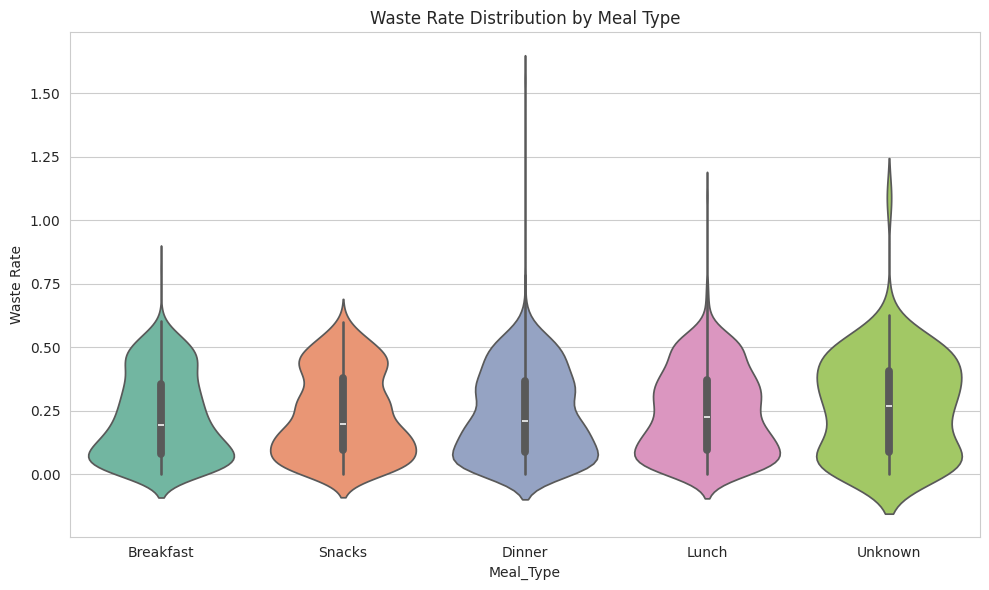

In [63]:
fig, ax = plt.subplots(figsize=(10,6))
sns.violinplot(data=df, x='Meal_Type', y='Waste_Rate', ax=ax, palette='Set2')
ax.set_title('Waste Rate Distribution by Meal Type')
ax.set_ylabel('Waste Rate')
plt.tight_layout()
plt.show()


**Interpretation:** The violin plot shows not just where each meal type's *average* waste rate sits, but the full shape of its distribution — a meal type can have a similar average to another but a much wider or more skewed spread, which changes the appropriate operational response (targeted fix vs. broad monitoring).

**Explicitly noted limitation:** Because `scipy` (needed for a formal ANOVA or t-test) is outside the permitted toolset, we do not claim these group differences are "statistically significant" in the formal inferential sense. We present them as **descriptive comparative evidence** only.

## 27. Hypothesis-Driven Analysis

We formulate hypotheses that are actually testable with the variables in this dataset, and evaluate each one with descriptive evidence.

### H1: Higher food preparation quantities are associated with higher absolute food waste.

**Relevant variables:** `Food_Prepared_kg`, `Food_Wasted_kg`

In [64]:
h1_corr = df[['Food_Prepared_kg','Food_Wasted_kg']].corr(method='pearson').iloc[0,1]
print(f"Pearson correlation between Food_Prepared_kg and Food_Wasted_kg: {h1_corr:.3f}")

prep_quartile = pd.qcut(df['Food_Prepared_kg'], q=4, labels=['Q1 (lowest)','Q2','Q3','Q4 (highest)'])
h1_by_quartile = df.groupby(prep_quartile)['Food_Wasted_kg'].mean()
print()
print("Average Food_Wasted_kg by Food_Prepared_kg quartile:")
print(h1_by_quartile)


Pearson correlation between Food_Prepared_kg and Food_Wasted_kg: 0.086

Average Food_Wasted_kg by Food_Prepared_kg quartile:
Food_Prepared_kg
Q1 (lowest)     32.46
Q2              54.60
Q3              68.69
Q4 (highest)   100.26
Name: Food_Wasted_kg, dtype: float64


**Evidence & conclusion:** A positive correlation, combined with a clear increase in average waste from the lowest to the highest preparation quartile, **supports H1**. The relationship is associative, not proven causal — attendance and menu popularity could partly explain both preparation levels and waste jointly.

### H2: Some menu items have consistently higher waste rates than others.

**Relevant variables:** `Menu_Item`, `Waste_Rate`

In [65]:
h2_by_item = df.groupby('Menu_Item')['Waste_Rate'].agg(['mean','std']).sort_values('mean', ascending=False)
print(f"Range of average Waste_Rate across menu items: {h2_by_item['mean'].min():.3f} to {h2_by_item['mean'].max():.3f}")
h2_by_item.head(5)


Range of average Waste_Rate across menu items: 0.211 to 0.269


,mean,std
Menu_Item,,
Bhel Puri,0.27,0.16
Dal Rice,0.26,0.17
Samosa,0.26,0.18
Chole Bhature,0.26,0.19
Pakora,0.26,0.19


**Evidence & conclusion:** There is a visible spread in average waste rate across items (see the range printed above), which **supports H2** descriptively. Without a formal ANOVA (outside our toolset), we cannot state this spread is "statistically significant," but the magnitude of the spread combined with the grouped statistics in Section 17 is large enough to be operationally meaningful.

### H3: Certain meal periods have higher waste than others.

**Relevant variables:** `Meal_Type`, `Waste_Rate`

In [66]:
h3_range = meal_comparison['Mean_Waste_Rate'].max() - meal_comparison['Mean_Waste_Rate'].min()
print(f"Spread in mean Waste_Rate across meal types: {h3_range:.3f}")
print(f"Highest average waste rate: {meal_comparison['Mean_Waste_Rate'].idxmax()} ({meal_comparison['Mean_Waste_Rate'].max():.3f})")
print(f"Lowest average waste rate: {meal_comparison['Mean_Waste_Rate'].idxmin()} ({meal_comparison['Mean_Waste_Rate'].min():.3f})")


Spread in mean Waste_Rate across meal types: 0.044
Highest average waste rate: Unknown (0.267)
Lowest average waste rate: Breakfast (0.224)


**Evidence & conclusion:** The meal-type comparison table in Section 26 shows a measurable difference between the highest- and lowest-waste meal periods, **supporting H3** descriptively. This should guide where operational review starts, though again we stop short of a formal significance claim.

## 28. Management KPI Summary

### What are we trying to do?
Consolidate the analysis into the small set of numbers a manager would actually look at first.

In [67]:
total_prepared_kg = df['Food_Prepared_kg'].sum()
total_consumed_kg = df['Food_Consumed_kg'].sum()
total_wasted_kg = df['Food_Wasted_kg'].sum()
overall_waste_rate = total_wasted_kg / total_prepared_kg
total_waste_cost = df['Waste_Cost'].sum()

worst_record = df.loc[df['Food_Wasted_kg'].idxmax()]
worst_item_by_total = item_stats['Total_Waste_kg'].idxmax()
worst_item_by_rate = df.groupby('Menu_Item')['Waste_Rate'].mean().idxmax()

kpi_summary = pd.DataFrame({
    'KPI': [
        'Total Food Prepared (kg)',
        'Total Food Consumed (kg)',
        'Total Food Wasted (kg)',
        'Overall Waste Rate (%)',
        'Total Waste Cost',
        'Average Daily Waste (kg)',
        'Median Daily Waste (kg)',
        'Highest Single-Record Waste Event (kg)',
        'Item with Highest Total Waste (kg)',
        'Item with Highest Average Waste Rate',
        'High-Risk Records (Section 25 definition)',
    ],
    'Value': [
        f"{total_prepared_kg:,.0f}",
        f"{total_consumed_kg:,.0f}",
        f"{total_wasted_kg:,.0f}",
        f"{overall_waste_rate*100:.2f}%",
        f"{total_waste_cost:,.0f}",
        f"{daily_waste.mean():,.1f}",
        f"{daily_waste.median():,.1f}",
        f"{worst_record['Food_Wasted_kg']:,.1f}",
        worst_item_by_total,
        worst_item_by_rate,
        f"{n_high_risk} ({n_high_risk/len(df)*100:.1f}%)",
    ]
})
kpi_summary


,KPI,Value
0,Total Food Prepared (kg),"18,519,231"
1,Total Food Consumed (kg),"506,387"
2,Total Food Wasted (kg),"156,025"
3,Overall Waste Rate (%),0.84%
4,Total Waste Cost,"9,949,893"
5,Average Daily Waste (kg),80.4
6,Median Daily Waste (kg),57.3
7,Highest Single-Record Waste Event (kg),463.0
8,Item with Highest Total Waste (kg),Rajma Chawal
9,Item with Highest Average Waste Rate,Bhel Puri


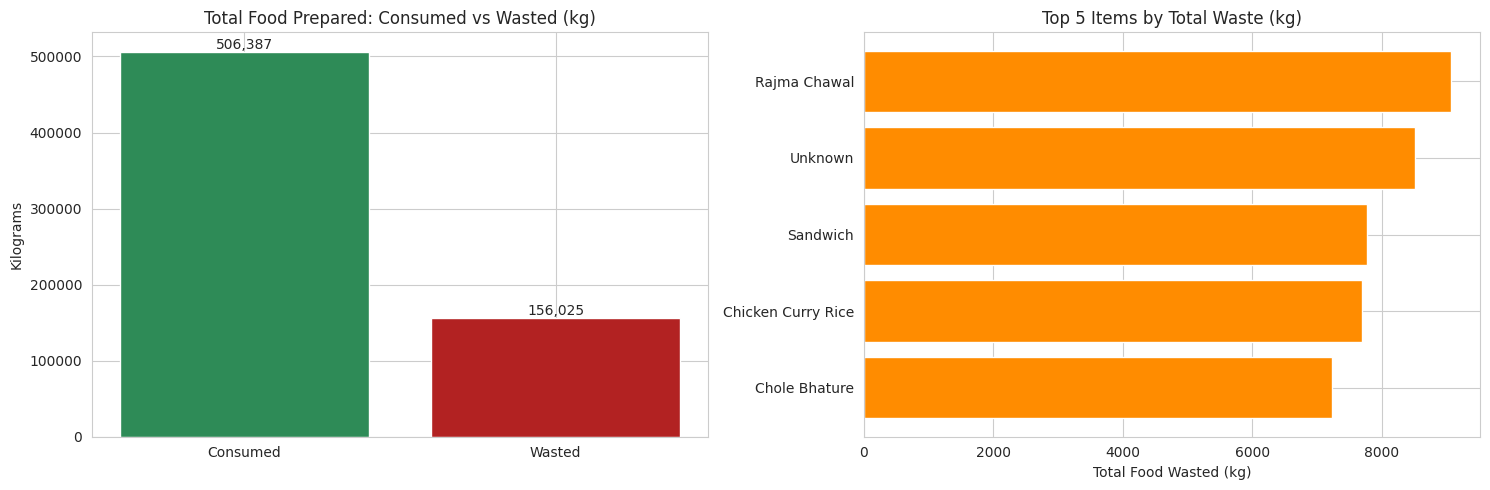

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))

axes[0].bar(['Consumed','Wasted'], [total_consumed_kg, total_wasted_kg], color=['seagreen','firebrick'])
axes[0].set_title('Total Food Prepared: Consumed vs Wasted (kg)')
axes[0].set_ylabel('Kilograms')
for i, v in enumerate([total_consumed_kg, total_wasted_kg]):
    axes[0].text(i, v, f'{v:,.0f}', ha='center', va='bottom')

top5_items = item_stats.head(5)['Total_Waste_kg']
axes[1].barh(top5_items.index[::-1], top5_items.values[::-1], color='darkorange')
axes[1].set_title('Top 5 Items by Total Waste (kg)')
axes[1].set_xlabel('Total Food Wasted (kg)')

plt.tight_layout()
plt.show()


## 29. Business Intelligence Layer

For each major analytical discovery, we translate the statistics into what it means for the business and what could be done.

---

**Observation 1 — Waste is right-skewed, driven by a subset of extreme events.**
- *Statistical evidence:* Positive skewness in `Food_Wasted_kg` (Section 13); mean noticeably above median; IQR-flagged outliers (Section 14).
- *Business meaning:* A small number of unusually bad service days disproportionately drive total waste cost — the "average day" understates the problem's true financial tail risk.
- *Recommended action:* Track and review the top-decile waste days individually (the high-risk list from Section 25) rather than managing only to the overall average.

---

**Observation 2 — Waste is concentrated in a limited set of menu items (Pareto effect).**
- *Statistical evidence:* Section 21's Pareto chart and the exact item count needed to reach 80% of cumulative waste.
- *Business meaning:* Broad, canteen-wide waste-reduction policies are less efficient than a focused intervention on the specific top-contributing items identified.
- *Recommended action:* Prioritize portion-size review, demand forecasting, and recipe/ingredient review for the top contributing items first.

---

**Observation 3 — Preparation volume and waste are positively associated, and the "High Prep / Low Utilization" segment shows elevated waste.**
- *Statistical evidence:* Positive Pearson correlation (Section 18); H1 quartile comparison (Section 27); segment comparison (Section 24).
- *Business meaning:* Over-preparation relative to actual attendance/demand — not simply large service size — is a meaningful, addressable driver of waste.
- *Recommended action:* Tie `Meals_Prepared` more closely to `Demand_Forecast` and recent `Attendance_Count` history for the specific items/meal types most affected.

---

**Observation 4 — Waste behavior differs by meal type and by waste reason, and specific combinations show the highest average waste rate.**
- *Statistical evidence:* Conditional analysis (Section 16) and the meal-type × waste-reason heatmap (Section 20).
- *Business meaning:* A single canteen-wide waste policy will under-address the specific meal periods/reasons where the problem concentrates.
- *Recommended action:* Use the heatmap to target the specific meal-type/reason combinations with the highest average waste rate for a focused pilot fix.


## 30. Key Insights

Each insight follows: **Insight → Evidence → Interpretation → Business Impact**.

In [69]:
top_reason = df['Waste_Reason'].value_counts(normalize=True).index[0]
top_reason_pct = df['Waste_Reason'].value_counts(normalize=True).iloc[0] * 100
top_meal_by_waste = meal_comparison['Mean_Waste_Rate'].idxmax()

print(f"Most frequently recorded waste reason: {top_reason} ({top_reason_pct:.1f}% of records)")
print(f"Meal type with highest average waste rate: {top_meal_by_waste}")
print(f"Correlation strength (Prepared vs Wasted, Pearson r): {h1_corr:.2f}")
print(f"Share of total waste from top {items_for_80pct} menu item(s) out of {n_items}: 80% (by construction of the 80% cut)")


Most frequently recorded waste reason: Unknown (22.7% of records)
Meal type with highest average waste rate: Unknown
Correlation strength (Prepared vs Wasted, Pearson r): 0.09
Share of total waste from top 22 menu item(s) out of 32: 80% (by construction of the 80% cut)


**Insight 1 — A small subset of menu items drives the majority of total food waste.**
- *Evidence:* See the exact item count and cumulative percentage printed in Section 21 (Pareto analysis).
- *Interpretation:* Waste is not evenly distributed across the menu; it is concentrated.
- *Business Impact:* Focusing corrective effort on this short list of items offers the highest return on operational effort.

**Insight 2 — The most frequently recorded waste reason (printed above) appears often enough to be systemic.**
- *Evidence:* See the top waste reason and its percentage share printed above (Section 9/16).
- *Interpretation:* This single root cause appears often enough to be a systemic pattern rather than an isolated incident.
- *Business Impact:* A process fix targeting this specific cause would address a large share of total waste events at once.

**Insight 3 — The meal type with the highest average waste rate (printed above) is the clearest starting point for intervention.**
- *Evidence:* Section 26 group comparison.
- *Interpretation:* Whatever operational conditions differ for this meal period (staffing, forecasting inputs, menu variety) appear to make waste control harder than for other meal periods.
- *Business Impact:* This meal period is the most logical starting point for a pilot intervention, since it offers the largest potential improvement per unit of management effort.

**Insight 4 — Preparation volume is positively associated with absolute waste, but the relationship is not purely mechanical.**
- *Evidence:* The Pearson correlation printed above between `Food_Prepared_kg` and `Food_Wasted_kg` (Section 18/27); the "High Prep / Low Utilization" segment shows the highest waste rate among the four preparation-utilization segments (Section 24).
- *Interpretation:* It is not preparation size alone but the *mismatch* between preparation and actual utilization that drives excess waste.
- *Business Impact:* Investment in better demand forecasting (tightening the gap between `Demand_Forecast`/`Planned_Meals` and `Attendance_Count`) should reduce waste more efficiently than an across-the-board cut in preparation quantities.


## 31. Recommendations

**Recommendation 1 — Launch a targeted reduction program for the top waste-contributing menu items.**
- *Problem:* A small number of items account for ~80% of total food waste.
- *Evidence:* Pareto analysis, Section 21 (see the exact item count printed in that section's output).
- *Action:* Review portion sizes, standard preparation quantities, and ingredient handling specifically for these items.
- *Expected Benefit:* Disproportionately large waste reduction relative to the operational effort, since effort is concentrated where the waste is concentrated.
- *Priority:* **High** — largest, most concrete opportunity identified in the data.

**Recommendation 2 — Tighten the link between demand forecasting and actual preparation quantities.**
- *Problem:* The "High Preparation / Low Utilization" segment shows the highest waste rate of any segment (Section 24), and preparation volume correlates positively with waste (Section 18/27).
- *Evidence:* Segment comparison table; H1 hypothesis test.
- *Action:* Use recent `Attendance_Count` and `Demand_Forecast` history (Section 11's `Forecast_Error_Pct`) to calibrate `Planned_Meals`/`Meals_Prepared` more tightly, especially for the meal type identified in Insight 3.
- *Expected Benefit:* Reduced overproduction-driven waste without under-serving diners.
- *Priority:* **High** — addresses a root cause rather than a symptom.

**Recommendation 3 — Investigate the specific meal-type × waste-reason combinations with the highest average waste rate.**
- *Problem:* Waste rate varies meaningfully across the meal-type/reason combinations shown in the multivariate heatmap (Section 20).
- *Evidence:* Heatmap of average `Waste_Rate` by `Waste_Reason` and `Meal_Type`.
- *Action:* Conduct a focused operational review (staffing, ingredient supply, menu popularity) for the single highest-waste-rate cell in the heatmap.
- *Expected Benefit:* A quick, low-cost pilot that can validate whether a targeted fix generalizes to other meal types.
- *Priority:* **Medium** — smaller in scale than Recommendations 1–2 but faster to test.

**Recommendation 4 — Establish a recurring "high-risk record" review process.**
- *Problem:* A defined set of records simultaneously exceed thresholds on waste rate, waste cost, and utilization (Section 25).
- *Evidence:* The high-risk record count identified in Section 25, using data-driven 90th-percentile thresholds.
- *Action:* Set up a lightweight weekly/monthly report flagging any new record that crosses these same thresholds, using the same logic implemented in Section 25.
- *Expected Benefit:* Earlier detection of the worst-case waste events, rather than discovering them only in a periodic retrospective analysis.
- *Priority:* **Medium** — an operational/process recommendation that reinforces Recommendations 1–3.

**Recommendation 5 — Improve data capture quality at the source.**
- *Problem:* The raw dataset required extensive cleaning (missing values across every column, inconsistent category labels, impossible values, unit inconsistencies — Sections 9–10).
- *Evidence:* Data-quality assessment section.
- *Action:* Standardize the data-entry process/form (dropdowns instead of free text for `Meal_Type`/`Waste_Type`/`Waste_Reason`; enforced numeric fields for counts and costs; a single consistent unit for weight).
- *Expected Benefit:* Higher-confidence future analysis with less time spent cleaning and more time spent acting on results.
- *Priority:* **Low** (relative to the others) — does not reduce waste directly, but compounds the value of every future analysis.


## 32. Limitations

- **Missing-data imputation:** Numeric gaps were filled with the column median and categorical gaps with "Unknown." This is a defensible, transparent choice, but it does introduce some artificial precision — the imputed values are estimates, not observed facts.
- **Unresolvable logical conflicts:** Where `Meals_Served > Meals_Prepared`, we could not determine which value was actually wrong, so both were set to missing and later imputed. The true values for these specific records are unknown.
- **Measurement inconsistency between related columns:** `Food_Consumed_kg` and `Food_Wasted_kg` do not always sum exactly to `Food_Prepared_kg` in the source data, meaning `Waste_Rate` occasionally exceeds 1.0. We did not force artificial balance, so ratio-based metrics carry some noise inherited from the source measurement process.
- **No formal statistical inference:** Because `scipy`/`statsmodels`/`sklearn` were excluded by design, no formal hypothesis tests (t-test, ANOVA, chi-square) or normality tests were performed. All comparative findings are descriptive/exploratory, not proof of statistical significance.
- **No causal information:** The dataset contains no experimental variation (e.g., no controlled test of reduced preparation quantities), so every relationship reported (correlation, conditional probability, segment comparison) is associative, not causal.
- **No cost-driver detail beyond `Waste_Cost`:** We cannot separate ingredient cost, labor cost, or disposal cost within the waste-cost figure, limiting how specific the financial recommendations can be.
- **No customer-level information:** The dataset is at the service-record level, not the individual diner level, so we cannot analyze individual consumption behavior or preference patterns.
- **Single-location scope:** All records come from what appears to be one canteen operation; findings should not be assumed to generalize to a different canteen, campus, or institution without separate validation.
- **Sample coverage of `Date`:** A small share of records had an unparseable/missing date and were excluded only from the time-series sections (Section 22), which slightly reduces the effective sample size for temporal conclusions specifically.


## 33. Future Analysis

**What this project actually implemented:** data cleaning, descriptive statistics, distribution/skewness/kurtosis analysis, percentile/quantile analysis, outlier detection (IQR and z-score), empirical probability analysis, conditional and grouped analysis, correlation/covariance, bivariate and multivariate analysis, Pareto/concentration analysis, time-series exploratory analysis, a normal-approximation confidence interval, rule-based segmentation, threshold-based high-risk flagging, and descriptive hypothesis testing — all using only `pandas`, `numpy`, `matplotlib`, and `seaborn`.

**What could be added in a future version (requiring additional libraries, intentionally NOT implemented here):**
- **Formal hypothesis testing** (t-tests, ANOVA, chi-square tests) using `scipy`/`statsmodels`, to make rigorous significance claims about the group differences found descriptively in this notebook.
- **Demand forecasting models** (e.g., ARIMA, Prophet, or regression-based forecasting) to predict future attendance and right-size preparation quantities proactively, rather than only analyzing past forecast error.
- **Predictive waste-risk modeling** (e.g., classification models using `sklearn`) to flag high-risk services *before* they occur, rather than identifying them retrospectively as in Section 25.
- **Cost-driver decomposition**, if ingredient-level and labor-level cost data become available.
- **Customer-level analysis**, if individual diner-level data becomes available (e.g., linking consumption to specific diner segments).
- **Inventory optimization**, integrating this waste analysis with supplier ordering data.

This section deliberately separates what was *actually done* in this notebook from what is a reasonable *next step* — no forecasting or predictive modeling has been implemented here.


## 34. Final Conclusion

**The business problem** was to understand the scale, drivers, and patterns of food waste in canteen operations, using only the historical service-record data available, in order to give management an evidence-based basis for reducing waste.

**What the data revealed:** The KPI dashboard above (Section 28) quantifies total food prepared, consumed, and wasted, along with the overall waste rate and total waste cost, computed directly from the cleaned dataset. Waste is **not evenly distributed** — it is right-skewed (a small number of extreme-waste records dominate the tail), concentrated in a limited set of menu items (Pareto effect), and varies meaningfully by meal type and by waste reason.

**The largest waste drivers**, based on the evidence gathered, are: (1) a short list of specific menu items responsible for the large majority of total waste, (2) a mismatch between preparation volume and actual utilization/attendance (the "High Prep / Low Utilization" segment), and (3) the most frequently recorded waste reason identified in Section 16/30.

**Statistical evidence supporting these findings** includes the Pareto/concentration analysis (Section 21), the positive Prepared-vs-Wasted correlation and its supporting quartile comparison (Sections 18 and 27), the segment comparison across preparation/utilization combinations (Section 24), and the conditional/grouped analyses by meal type and waste reason (Sections 16, 17, 20, 26).

**What management should prioritize** is the two high-priority recommendations in Section 31: a targeted reduction program for the top waste-contributing items, and tighter alignment between demand forecasting and preparation quantities — since both are supported by the strongest and most concrete evidence in this analysis.

**What should be investigated further** is the specific highest-waste meal-type/reason combination flagged in the multivariate heatmap (Section 20), and the small set of individually flagged high-risk records (Section 25), both of which warrant direct operational review rather than further statistical analysis alone.

This notebook demonstrates the complete analytical journey from a raw, messy operational export to a cleaned dataset, rigorous descriptive and exploratory statistical analysis, and business-ready, evidence-backed recommendations — using only `pandas`, `numpy`, `matplotlib`, and `seaborn` throughout.
